# 1 -verifikasi-verifikasi

In [ ]:
import numpy as np
from numpy import sin, cos, exp
from scipy.linalg import expm
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=False)

## patameter uji

In [ ]:
# Konversi natural unit
# 1 km = 5.0677307 × 10^9 eV^-1

KM_TO_EV_INV = 5.0677307e9

In [ ]:
# ==============================
# Parameter Materi
# ==============================

rho = 3.0  # Densitas massa materi (g/cm^3)

# Asumsi fraksi elektron (Ye = 1.0 digunakan sebagai basis penyederhanaan kalkulasi)
Ye = 0.5

# Potensial materi arus bermuatan (Charged-Current Matter Potential)
# Rumus umum: Vcc ≈ 7.6 × 10^-14 × Ye × rho (eV)
Vcc_rho = 7.6e-14 * Ye * rho

print(f"rho = {rho} g/cm^3")
print(f"Ye  = {Ye} (asumsi)")
print(f"Vcc = {Vcc_rho:.2e} eV")

rho = 3.0 g/cm^3
Ye  = 0.5 (asumsi)
Vcc = 1.14e-13 eV


In [ ]:
# Mixing angles (degree -> radian)
theta12 = np.deg2rad(33.66)
theta23 = np.deg2rad(49.1)
theta13 = np.deg2rad(8.54)
delta_cp = np.deg2rad(197)

# Mass-squared differences (eV^2)
dm21 = 7.41e-5
dm31 = 2.514e-3

# Energy (eV)
E = 1e9  # 1 GeV

# Baseline (km)
L = 1300

# Matter potential (eV)
Vcc = 1.14e-13  #subs dari nilai Vcc diatas

print("theta12 =", theta12, "rad")
print("theta23 =", theta23, "rad")
print("theta13 =", theta13, "rad")
print("delta_cp =", delta_cp, "rad")
print("dm21 =", dm21, "eV^2")
print("dm31 =", dm31, "eV^2")
print("E =", E, "eV")
print("L =", L, "km")
print("Vcc =", Vcc, "eV")

theta12 = 0.5874778262212913 rad
theta23 = 0.8569566627292158 rad
theta13 = 0.14905111812031574 rad
delta_cp = 3.4382986264288293 rad
dm21 = 7.41e-05 eV^2
dm31 = 0.002514 eV^2
E = 1000000000.0 eV
L = 1300 km
Vcc = 1.14e-13 eV


## uji unitaritas pmns

In [ ]:
def U_PMNS(t12, t23, t13, delta):
    c12, s12 = cos(t12), sin(t12)
    c23, s23 = cos(t23), sin(t23)
    c13, s13 = cos(t13), sin(t13)

    e_minus = exp(-1j * delta)
    e_plus  = exp(1j * delta)

    U = np.array([
        [c12*c13,
         s12*c13,
         s13*e_minus],

        [-s12*c23 - c12*s23*s13*e_plus,
         c12*c23 - s12*s23*s13*e_plus,
         s23*c13],

        [s12*s23 - c12*c23*s13*e_plus,
         -c12*s23 - s12*c23*s13*e_plus,
         c23*c13]
    ], dtype=complex)

    return U

In [ ]:
U = U_PMNS(theta12, theta23, theta13, delta_cp)

print("Matriks PMNS U:")
print(U)

print("\nmax |U_ij| =", np.max(np.abs(U)))

Matriks PMNS U:
[[ 0.8231+0.j      0.5481+0.j     -0.142 +0.0434j]
 [-0.2736+0.0273j  0.6045+0.0182j  0.7475+0.j    ]
 [ 0.4963+0.0237j -0.5776+0.0158j  0.6475+0.j    ]]

max |U_ij| = 0.8231126332991259


In [ ]:
check = U.conj().T @ U
print(check)

[[ 1.0000e+00+0.0000e+00j  1.9732e-17-4.3368e-19j  8.1971e-18+0.0000e+00j]
 [ 1.9732e-17+4.3368e-19j  1.0000e+00+0.0000e+00j -1.5615e-16+3.4694e-18j]
 [ 8.1971e-18+0.0000e+00j -1.5615e-16-3.4694e-18j  1.0000e+00+0.0000e+00j]]


In [ ]:
def check_unitarity(M):
    I = np.eye(M.shape[0], dtype=complex)

    product = M.conj().T @ M
    deviation = product - I
    error = np.linalg.norm(deviation)
    is_unitary = np.allclose(product, I)

    return deviation, error, is_unitary


dev_U, err_U, is_U_unitary = check_unitarity(U)

print("Deviasi U†U - I:")
print(dev_U)

print("\nError unitaritas =", err_U)
print("Uniter?", is_U_unitary)

Deviasi U†U - I:
[[-1.1102e-16+0.0000e+00j  1.9732e-17-4.3368e-19j  8.1971e-18+0.0000e+00j]
 [ 1.9732e-17+4.3368e-19j  0.0000e+00+0.0000e+00j -1.5615e-16+3.4694e-18j]
 [ 8.1971e-18+0.0000e+00j -1.5615e-16-3.4694e-18j -1.1102e-16+0.0000e+00j]]

Error unitaritas = 2.726835365120513e-16
Uniter? True


## uji hermitian Hamilton

### vakum

In [ ]:
def Hamiltonian_vacuum(U, E, dm21, dm31):
    M2 = np.diag([0, dm21, dm31])

    H_mass = M2 / (2 * E)

    H_vac = U @ H_mass @ U.conj().T

    return H_vac


H_vac = Hamiltonian_vacuum(U, E, dm21, dm31)

print("Hamiltonian vakum:")
print(H_vac)

Hamiltonian vakum:
[[ 3.8851e-14+1.5777e-30j -1.2115e-13+4.0424e-14j -1.2731e-13+3.5017e-14j]
 [-1.2115e-13-4.0424e-14j  7.1586e-13+4.9304e-32j  5.9543e-13-7.4211e-16j]
 [-1.2731e-13-3.5017e-14j  5.9543e-13+7.4211e-16j  5.3934e-13+0.0000e+00j]]


In [ ]:
def check_hermitian(H):
    deviation = H - H.conj().T
    error = np.linalg.norm(deviation)
    is_hermitian = np.allclose(H, H.conj().T)

    return deviation, error, is_hermitian


dev_H_vac, err_H_vac, is_H_vac_hermitian = check_hermitian(H_vac)

print("Deviasi H_vac - H_vac†:")
print(dev_H_vac)

print("\nError Hermitian =", err_H_vac)
print("Hermitian?", is_H_vac_hermitian)

Deviasi H_vac - H_vac†:
[[0.+3.1554e-30j 0.-6.3109e-30j 0.+0.0000e+00j]
 [0.-6.3109e-30j 0.+9.8608e-32j 0.+0.0000e+00j]
 [0.+0.0000e+00j 0.+0.0000e+00j 0.+0.0000e+00j]]

Error Hermitian = 9.466844430039616e-30
Hermitian? True


### materi

In [ ]:
# =========================
# Hamiltonian materi (MSW)
# =========================

def Hamiltonian_matter(U, E, dm21, dm31, Vcc):
    H_vac = Hamiltonian_vacuum(U, E, dm21, dm31)

    H_mat = np.array([
        [Vcc, 0, 0],
        [0,   0, 0],
        [0,   0, 0]
    ], dtype=complex)

    H_total = H_vac + H_mat

    return H_total


H_mat_total = Hamiltonian_matter(U, E, dm21, dm31, Vcc)

print("Hamiltonian total dalam materi:")
print(H_mat_total)

print("\nTambahan efek materi:")
print(H_mat_total - H_vac)

Hamiltonian total dalam materi:
[[ 1.5285e-13+1.5777e-30j -1.2115e-13+4.0424e-14j -1.2731e-13+3.5017e-14j]
 [-1.2115e-13-4.0424e-14j  7.1586e-13+4.9304e-32j  5.9543e-13-7.4211e-16j]
 [-1.2731e-13-3.5017e-14j  5.9543e-13+7.4211e-16j  5.3934e-13+0.0000e+00j]]

Tambahan efek materi:
[[1.14e-13+0.j 0.00e+00+0.j 0.00e+00+0.j]
 [0.00e+00+0.j 0.00e+00+0.j 0.00e+00+0.j]
 [0.00e+00+0.j 0.00e+00+0.j 0.00e+00+0.j]]


In [ ]:
dev_H_mat, err_H_mat, is_H_mat_hermitian = check_hermitian(H_mat_total)

print("Deviasi H_matter - H_matter†:")
print(dev_H_mat)

print("\nError Hermitian =", err_H_mat)
print("Hermitian?", is_H_mat_hermitian)

Deviasi H_matter - H_matter†:
[[0.+3.1554e-30j 0.-6.3109e-30j 0.+0.0000e+00j]
 [0.-6.3109e-30j 0.+9.8608e-32j 0.+0.0000e+00j]
 [0.+0.0000e+00j 0.+0.0000e+00j 0.+0.0000e+00j]]

Error Hermitian = 9.466844430039616e-30
Hermitian? True


## uji untaritas operator evolusi


In [ ]:
def evolution_operator_vacuum(U, E, L_km, dm21, dm31):
    H = Hamiltonian_vacuum(U, E, dm21, dm31)

    L_eV_inv = L_km * KM_TO_EV_INV

    S = expm(-1j * H * L_eV_inv)

    return S


def evolution_operator_matter(U, E, L_km, dm21, dm31, Vcc):
    H = Hamiltonian_matter(U, E, dm21, dm31, Vcc)

    L_eV_inv = L_km * KM_TO_EV_INV

    S = expm(-1j * H * L_eV_inv)

    return S


S_vac = evolution_operator_vacuum(U, E, L, dm21, dm31)
S_mat = evolution_operator_matter(U, E, L, dm21, dm31, Vcc)

print("Operator evolusi vakum:")
print(S_vac)

print("\nOperator evolusi materi:")
print(S_mat)

Operator evolusi vakum:
[[ 0.9599-0.0927j  0.1674-0.0291j  0.1629+0.1207j]
 [ 0.1132+0.0621j  0.199 -0.5969j -0.679 -0.3556j]
 [ 0.1159+0.1997j -0.6693-0.3568j  0.3972-0.4622j]]

Operator evolusi materi:
[[ 0.6562-0.7241j  0.1028-0.0814j  0.1568+0.0568j]
 [ 0.0898-0.002j   0.1832-0.5989j -0.687 -0.3575j]
 [ 0.1455+0.1256j -0.6777-0.3623j  0.3956-0.4647j]]


In [ ]:
dev_S_vac, err_S_vac, is_S_vac_unitary = check_unitarity(S_vac)
dev_S_mat, err_S_mat, is_S_mat_unitary = check_unitarity(S_mat)

print("Vakum")
print("Error unitaritas S_vac =", err_S_vac)
print("Uniter?", is_S_vac_unitary)

print("\nMateri")
print("Error unitaritas S_mat =", err_S_mat)
print("Uniter?", is_S_mat_unitary)

Vakum
Error unitaritas S_vac = 6.748230400263182e-16
Uniter? True

Materi
Error unitaritas S_mat = 7.980180513221142e-16
Uniter? True


## uji konservasi probabilitas

In [ ]:
flavor_index = {
    "e": 0,
    "mu": 1,
    "tau": 2
}


def probability_from_S(S, alpha, beta):
    a = flavor_index[alpha]
    b = flavor_index[beta]

    P = np.abs(S[b, a])**2

    return P


def probability_matrix(S):
    P = np.abs(S)**2

    return P

In [ ]:
P_vac = probability_matrix(S_vac)
P_mat = probability_matrix(S_mat)

print("Matriks probabilitas vakum P[akhir, awal]:")
print(P_vac)

print("\nMatriks probabilitas materi P[akhir, awal]:")
print(P_mat)

print("\nP(nu_mu -> nu_e) vakum =", probability_from_S(S_vac, "mu", "e"))
print("P(nu_mu -> nu_e) materi =", probability_from_S(S_mat, "mu", "e"))

Matriks probabilitas vakum P[akhir, awal]:
[[0.93   0.0289 0.0411]
 [0.0167 0.3959 0.5875]
 [0.0533 0.5753 0.3714]]

Matriks probabilitas materi P[akhir, awal]:
[[0.955  0.0172 0.0278]
 [0.0081 0.3922 0.5997]
 [0.0369 0.5906 0.3725]]

P(nu_mu -> nu_e) vakum = 0.02887943450772671
P(nu_mu -> nu_e) materi = 0.017205877913423633


In [ ]:
def check_probability_conservation(S):
    P = probability_matrix(S)

    column_sums = np.sum(P, axis=0)

    deviation = column_sums - np.ones(3)
    error = np.linalg.norm(deviation)
    is_conserved = np.allclose(column_sums, np.ones(3))

    return P, column_sums, deviation, error, is_conserved


P_vac, sum_vac, dev_prob_vac, err_prob_vac, cons_vac = check_probability_conservation(S_vac)
P_mat, sum_mat, dev_prob_mat, err_prob_mat, cons_mat = check_probability_conservation(S_mat)

print("Vakum")
print("Jumlah probabilitas tiap flavor awal =", sum_vac)
print("Deviasi =", dev_prob_vac)
print("Error =", err_prob_vac)
print("Terkonservasi?", cons_vac)

print("\nMateri")
print("Jumlah probabilitas tiap flavor awal =", sum_mat)
print("Deviasi =", dev_prob_mat)
print("Error =", err_prob_mat)
print("Terkonservasi?", cons_mat)

Vakum
Jumlah probabilitas tiap flavor awal = [1. 1. 1.]
Deviasi = [-1.1102e-16  8.8818e-16  4.4409e-16]
Error = 9.992007221626409e-16
Terkonservasi? True

Materi
Jumlah probabilitas tiap flavor awal = [1. 1. 1.]
Deviasi = [ 0.0000e+00 -1.1102e-16 -4.4409e-16]
Error = 4.577566798522237e-16
Terkonservasi? True


## uji konservasi probabilitas di range energi neutrino


In [ ]:
# ==========================================================
# Uji konservasi probabilitas terhadap energi neutrino
# ==========================================================

# Rentang energi untuk sumbu grafik
energy_values_GeV = np.linspace(0.5, 10.0, 300)

# Menyimpan hasil kondisi vakum
vac_initial_sums = []
vac_final_sums = []

# Menyimpan hasil kondisi materi
mat_initial_sums = []
mat_final_sums = []

for E_GeV in energy_values_GeV:

    # Konversi energi GeV ke eV
    E_val = E_GeV * 1e9

    # Matriks PMNS memakai parameter best fit
    U_val = U_PMNS(
        theta12,
        theta23,
        theta13,
        delta_cp
    )

    # --------------------------
    # Kondisi vakum
    # --------------------------
    S_vac_E = evolution_operator_vacuum(
        U_val,
        E_val,
        L,
        dm21,
        dm31
    )

    P_vac_E = probability_matrix(S_vac_E)

    # Jumlah untuk setiap flavor awal:
    # jumlah tiap kolom
    vac_initial_sums.append(
        np.sum(P_vac_E, axis=0)
    )

    # Jumlah untuk setiap flavor akhir:
    # jumlah tiap baris
    vac_final_sums.append(
        np.sum(P_vac_E, axis=1)
    )

    # --------------------------
    # Kondisi materi
    # --------------------------
    S_mat_E = evolution_operator_matter(
        U_val,
        E_val,
        L,
        dm21,
        dm31,
        Vcc_rho
    )

    P_mat_E = probability_matrix(S_mat_E)

    # Jumlah untuk setiap flavor awal
    mat_initial_sums.append(
        np.sum(P_mat_E, axis=0)
    )

    # Jumlah untuk setiap flavor akhir
    mat_final_sums.append(
        np.sum(P_mat_E, axis=1)
    )

# Ubah list menjadi array NumPy
vac_initial_sums = np.asarray(vac_initial_sums)
vac_final_sums = np.asarray(vac_final_sums)

mat_initial_sums = np.asarray(mat_initial_sums)
mat_final_sums = np.asarray(mat_final_sums)

print("Perhitungan uji konservasi terhadap energi selesai.")
print("Bentuk data vakum, flavor awal =", vac_initial_sums.shape)
print("Bentuk data vakum, flavor akhir =", vac_final_sums.shape)

Perhitungan uji konservasi terhadap energi selesai.
Bentuk data vakum, flavor awal = (300, 3)
Bentuk data vakum, flavor akhir = (300, 3)


### flavor awal

In [ ]:
def plot_initial_flavor_conservation(
    energy_GeV,
    sums,
    condition_label
):
    """
    Menampilkan jumlah probabilitas seluruh flavor akhir
    untuk masing-masing flavor awal.
    """

    plt.figure(figsize=(8, 5))

    # Flavor awal elektron
    plt.plot(
        energy_GeV,
        sums[:, 0],
        label=(
            r"$P_{ee}+P_{e\mu}+P_{e\tau}$"
        )
    )

    # Flavor awal muon
    plt.plot(
        energy_GeV,
        sums[:, 1],
        linestyle="--",
        label=(
            r"$P_{\mu e}+P_{\mu\mu}+P_{\mu\tau}$"
        )
    )

    # Flavor awal tau
    plt.plot(
        energy_GeV,
        sums[:, 2],
        linestyle=":",
        label=(
            r"$P_{\tau e}+P_{\tau\mu}+P_{\tau\tau}$"
        )
    )


    plt.xlabel("Energi neutrino (GeV)")
    plt.ylabel("Jumlah probabilitas")
    plt.title(
        f"Konservasi Probabilitas Berdasarkan "
        f"Flavor Awal — {condition_label}"
    )

    plt.grid(True)
    plt.legend()
    plt.ylim(0.999999999999, 1.000000000001)
    plt.tight_layout()
    plt.show()

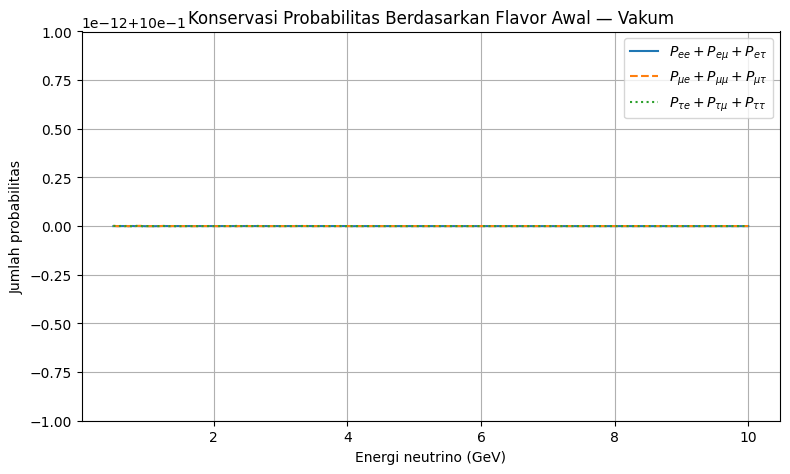

In [ ]:
plot_initial_flavor_conservation(
    energy_GeV=energy_values_GeV,
    sums=vac_initial_sums,
    condition_label="Vakum"
)


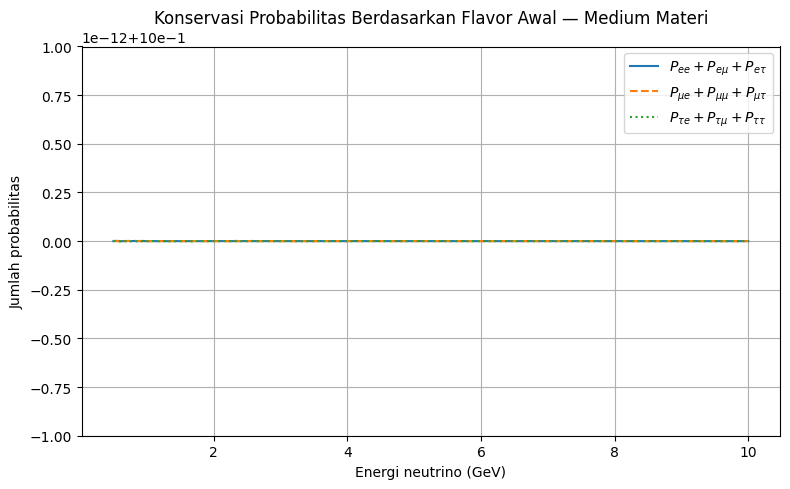

In [ ]:
plot_initial_flavor_conservation(
    energy_GeV=energy_values_GeV,
    sums=mat_initial_sums,
    condition_label="Medium Materi"
)

### flavor akhir


In [ ]:
def plot_final_flavor_conservation(
    energy_GeV,
    sums,
    condition_label
):
    """
    Menampilkan jumlah probabilitas seluruh flavor awal
    menuju masing-masing flavor akhir.
    """

    plt.figure(figsize=(8, 5))

    # Flavor akhir elektron
    plt.plot(
        energy_GeV,
        sums[:, 0],
        label=(
            r"$P_{ee}+P_{\mu e}+P_{\tau e}$"
        )
    )

    # Flavor akhir muon
    plt.plot(
        energy_GeV,
        sums[:, 1],
        linestyle="--",
        label=(
            r"$P_{e\mu}+P_{\mu\mu}+P_{\tau\mu}$"
        )
    )

    # Flavor akhir tau
    plt.plot(
        energy_GeV,
        sums[:, 2],
        linestyle=":",
        label=(
            r"$P_{e\tau}+P_{\mu\tau}+P_{\tau\tau}$"
        )
    )

    plt.xlabel("Energi neutrino (GeV)")
    plt.ylabel("Jumlah probabilitas")
    plt.title(
        f"Konservasi Probabilitas Berdasarkan "
        f"Flavor Akhir — {condition_label}"
    )

    plt.grid(True)
    plt.legend()
    plt.ylim(0.999999999999, 1.000000000001)
    plt.tight_layout()
    plt.show()

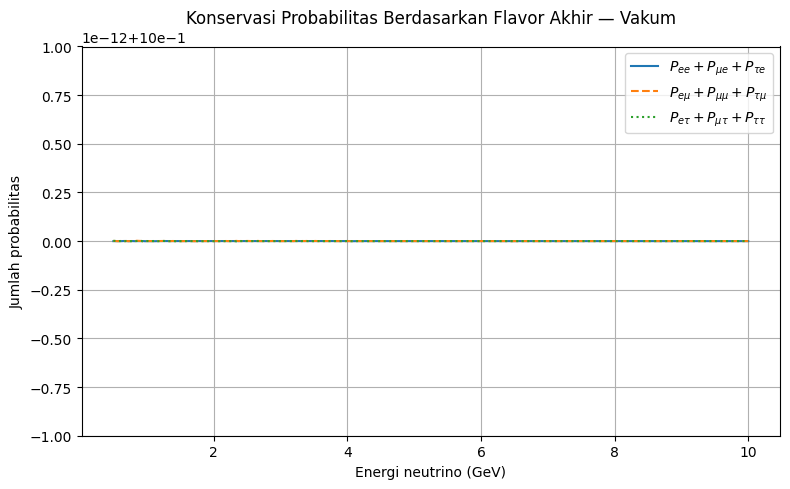

In [ ]:
plot_final_flavor_conservation(
    energy_GeV=energy_values_GeV,
    sums=vac_final_sums,
    condition_label="Vakum"
)

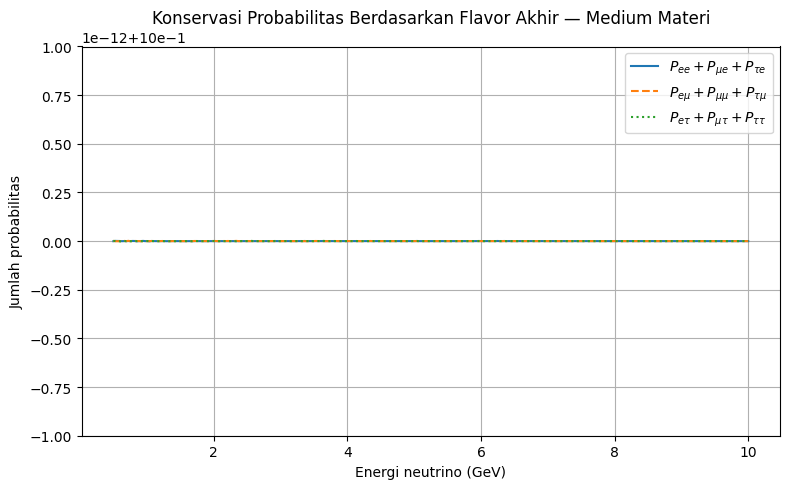

In [ ]:
plot_final_flavor_conservation(
    energy_GeV=energy_values_GeV,
    sums=mat_final_sums,
    condition_label="Medium Materi"
)

In [ ]:
# Deviasi terhadap nilai teoritis 1
vac_initial_dev = vac_initial_sums - 1.0
vac_final_dev = vac_final_sums - 1.0

mat_initial_dev = mat_initial_sums - 1.0
mat_final_dev = mat_final_sums - 1.0

print("Deviasi maksimum absolut:")

print(
    "Vakum, berdasarkan flavor awal =",
    np.max(np.abs(vac_initial_dev))
)

print(
    "Vakum, berdasarkan flavor akhir =",
    np.max(np.abs(vac_final_dev))
)

print(
    "Materi, berdasarkan flavor awal =",
    np.max(np.abs(mat_initial_dev))
)

print(
    "Materi, berdasarkan flavor akhir =",
    np.max(np.abs(mat_final_dev))
)

Deviasi maksimum absolut:
Vakum, berdasarkan flavor awal = 1.3322676295501878e-15
Vakum, berdasarkan flavor akhir = 1.5543122344752192e-15
Materi, berdasarkan flavor awal = 1.4432899320127035e-15
Materi, berdasarkan flavor akhir = 1.4432899320127035e-15


# 2 -comot data pakai monte carlo

In [ ]:
# ==============================
# Parameter NuFIT 1 sigma
# Normal Ordering, IC24
# ==============================

nufit_1sigma = {
    "theta12_deg": {
        "best": 33.76,
        "min": 33.76 - 0.41,
        "max": 33.76 + 0.42
    },

    "theta23_deg": {
        "best": 43.29,
        "min": 43.29 - 0.79,
        "max": 43.29 + 0.96
    },

    "theta13_deg": {
        "best": 8.62,
        "min": 8.62 - 0.11,
        "max": 8.62 + 0.11
    },

    "delta_cp_deg": {
        "best": 212,
        "min": 212 - 36,
        "max": 212 + 26
    },

    "dm21": {
        "best": 7.537e-5,
        "min": (7.537 - 0.10) * 1e-5,
        "max": (7.537 + 0.094) * 1e-5
    },

    "dm31": {
        "best": 2.511e-3,
        "min": (2.511 - 0.020) * 1e-3,
        "max": (2.511 + 0.021) * 1e-3
    }
}

for name, values in nufit_1sigma.items():
    print(name)
    print("  best =", values["best"])
    print("  min  =", values["min"])
    print("  max  =", values["max"])
    print()

theta12_deg
  best = 33.76
  min  = 33.35
  max  = 34.18

theta23_deg
  best = 43.29
  min  = 42.5
  max  = 44.25

theta13_deg
  best = 8.62
  min  = 8.51
  max  = 8.729999999999999

delta_cp_deg
  best = 212
  min  = 176
  max  = 238

dm21
  best = 7.537e-05
  min  = 7.437000000000001e-05
  max  = 7.631e-05

dm31
  best = 0.002511
  min  = 0.002491
  max  = 0.002532



In [ ]:
# ==============================
# Sampling Monte Carlo
# ==============================

N_samples = 5000
seed = 42

rng = np.random.default_rng(seed)

theta12_samples_deg = rng.uniform(
    nufit_1sigma["theta12_deg"]["min"],
    nufit_1sigma["theta12_deg"]["max"],
    N_samples
)

theta23_samples_deg = rng.uniform(
    nufit_1sigma["theta23_deg"]["min"],
    nufit_1sigma["theta23_deg"]["max"],
    N_samples
)

theta13_samples_deg = rng.uniform(
    nufit_1sigma["theta13_deg"]["min"],
    nufit_1sigma["theta13_deg"]["max"],
    N_samples
)

delta_cp_samples_deg = rng.uniform(
    nufit_1sigma["delta_cp_deg"]["min"],
    nufit_1sigma["delta_cp_deg"]["max"],
    N_samples
)

dm21_samples = rng.uniform(
    nufit_1sigma["dm21"]["min"],
    nufit_1sigma["dm21"]["max"],
    N_samples
)

dm31_samples = rng.uniform(
    nufit_1sigma["dm31"]["min"],
    nufit_1sigma["dm31"]["max"],
    N_samples
)

print("Sampling Monte Carlo selesai.")
print("Jumlah sampel =", N_samples)
print("Seed =", seed)

Sampling Monte Carlo selesai.
Jumlah sampel = 5000
Seed = 42


In [ ]:
# ==============================
# Konversi degree ke radian
# ==============================

theta12_samples = np.deg2rad(theta12_samples_deg)
theta23_samples = np.deg2rad(theta23_samples_deg)
theta13_samples = np.deg2rad(theta13_samples_deg)
delta_cp_samples = np.deg2rad(delta_cp_samples_deg)

print("Contoh theta12 dalam derajat:")
print(theta12_samples_deg[:5])

print("\nContoh theta12 dalam radian:")
print(theta12_samples[:5])

Contoh theta12 dalam derajat:
[33.9924 33.7143 34.0626 33.9288 33.4282]

Contoh theta12 dalam radian:
[0.5933 0.5884 0.5945 0.5922 0.5834]


In [ ]:
# ==============================
# Mengurutkan hasil sampling Monte Carlo
# ==============================

# Theta12
idx = np.argsort(theta12_samples_deg)
theta12_samples_deg = theta12_samples_deg[idx]
theta12_samples = theta12_samples[idx]

# Theta13
idx = np.argsort(theta13_samples_deg)
theta13_samples_deg = theta13_samples_deg[idx]
theta13_samples = theta13_samples[idx]

# Theta23
idx = np.argsort(theta23_samples_deg)
theta23_samples_deg = theta23_samples_deg[idx]
theta23_samples = theta23_samples[idx]

# Delta CP
idx = np.argsort(delta_cp_samples_deg)
delta_cp_samples_deg = delta_cp_samples_deg[idx]
delta_cp_samples = delta_cp_samples[idx]

# Δm²21
dm21_samples = np.sort(dm21_samples)

# Δm²31
dm31_samples = np.sort(dm31_samples)

print("Semua hasil sampling berhasil diurutkan.")

print("\n5 nilai pertama θ12:")
print(theta12_samples_deg[:5])

print("\n5 nilai pertama θ13:")
print(theta13_samples_deg[:5])

print("\n5 nilai pertama θ23:")
print(theta23_samples_deg[:5])

print("\n5 nilai pertama δCP:")
print(delta_cp_samples_deg[:5])

print("\n5 nilai pertama Δm²21:")
print(dm21_samples[:5])

print("\n5 nilai pertama Δm²31:")
print(dm31_samples[:5])

Semua hasil sampling berhasil diurutkan.

5 nilai pertama θ12:
[33.3504 33.3505 33.3505 33.3507 33.3508]

5 nilai pertama θ13:
[8.51   8.51   8.51   8.5101 8.5102]

5 nilai pertama θ23:
[42.5006 42.5007 42.501  42.5017 42.5018]

5 nilai pertama δCP:
[176.0012 176.0031 176.0067 176.0344 176.0402]

5 nilai pertama Δm²21:
[7.4370e-05 7.4370e-05 7.4371e-05 7.4371e-05 7.4371e-05]

5 nilai pertama Δm²31:
[0.0025 0.0025 0.0025 0.0025 0.0025]


In [ ]:
import pandas as pd

# ==============================
# Simpan hasil sampling
# ==============================

mc_samples = pd.DataFrame({
    "theta12_deg": theta12_samples_deg,
    "theta13_deg": theta13_samples_deg,
    "theta23_deg": theta23_samples_deg,
    "delta_cp_deg": delta_cp_samples_deg,
    "theta12_rad": theta12_samples,
    "theta13_rad": theta13_samples,
    "theta23_rad": theta23_samples,
    "delta_cp_rad": delta_cp_samples,
    "dm21_eV2": dm21_samples,
    "dm31_eV2": dm31_samples
})

print("Ukuran data sampling:")
print(mc_samples.shape)

mc_samples.head(10)

Ukuran data sampling:
(5000, 10)


,theta12_deg,theta13_deg,theta23_deg,delta_cp_deg,theta12_rad,theta13_rad,theta23_rad,delta_cp_rad,dm21_eV2,dm31_eV2
0,33.350431,8.510003,42.500550,176.001193,0.582075,0.148528,0.741775,3.071800,0.000074,0.002491
1,33.350472,8.510027,42.500730,176.003139,0.582076,0.148528,0.741778,3.071834,0.000074,0.002491
2,33.350533,8.510044,42.500999,176.006745,0.582077,0.148528,0.741782,3.071897,0.000074,0.002491
3,33.350684,8.510099,42.501672,176.034358,0.582079,0.148529,0.741794,3.072379,0.000074,0.002491
4,33.350769,8.510152,42.501841,176.040200,0.582081,0.148530,0.741797,3.072481,0.000074,0.002491
5,33.350822,8.510228,42.501911,176.042411,0.582082,0.148532,0.741798,3.072520,0.000074,0.002491
6,33.350824,8.510280,42.502257,176.042858,0.582082,0.148532,0.741804,3.072527,0.000074,0.002491
7,33.350886,8.510290,42.503018,176.070728,0.582083,0.148533,0.741818,3.073014,0.000074,0.002491
8,33.351023,8.510346,42.503281,176.073809,0.582085,0.148534,0.741822,3.073068,0.000074,0.002491
9,33.351354,8.510504,42.503953,176.081723,0.582091,0.148536,0.741834,3.073206,0.000074,0.002491


In [ ]:
# ==============================
# Statistik hasil sampling
# ==============================

display(mc_samples.describe())

,theta12_deg,theta13_deg,theta23_deg,delta_cp_deg,theta12_rad,theta13_rad,theta23_rad,delta_cp_rad,dm21_eV2,dm31_eV2
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000
mean,33.761358,8.620355,43.372604,207.263896,0.589247,0.150454,0.756995,3.617437,7.534041e-05,0.002512
std,0.239477,0.063001,0.503887,18.073950,0.004180,0.001100,0.008794,0.315450,5.615396e-07,0.000012
min,33.350431,8.510003,42.500550,176.001193,0.582075,0.148528,0.741775,3.071800,7.437033e-05,0.002491
25%,33.552859,8.564969,42.935072,191.506516,0.585608,0.149487,0.749358,3.342419,7.485544e-05,0.002501
50%,33.758346,8.621137,43.383651,207.607433,0.589194,0.150467,0.757188,3.623433,7.533902e-05,0.002512
75%,33.971389,8.674507,43.799055,222.879201,0.592913,0.151399,0.764438,3.889976,7.583925e-05,0.002522
max,34.179805,8.729988,44.249960,237.972657,0.596550,0.152367,0.772307,4.153406,7.630997e-05,0.002532


In [ ]:
# ==============================
# Simpan hasil sampling ke file CSV
# ==============================

filename = "hasil_sampling_monte_carlo_nufit_1sigma.csv"

mc_samples.to_csv(filename, index=False)

print("File berhasil disimpan:")
print(filename)

File berhasil disimpan:
hasil_sampling_monte_carlo_nufit_1sigma.csv


In [ ]:
# ==============================
# Ambil satu sampel acak
# ==============================

idx = rng.integers(0, N_samples)

sample = mc_samples.iloc[idx]

theta12_mc = sample["theta12_rad"]
theta13_mc = sample["theta13_rad"]
theta23_mc = sample["theta23_rad"]
delta_cp_mc = sample["delta_cp_rad"]
dm21_mc = sample["dm21_eV2"]
dm31_mc = sample["dm31_eV2"]

print("Index sampel terpilih =", idx)
print()
print("theta12 =", sample["theta12_deg"], "deg")
print("theta13 =", sample["theta13_deg"], "deg")
print("theta23 =", sample["theta23_deg"], "deg")
print("deltaCP =", sample["delta_cp_deg"], "deg")
print("dm21 =", dm21_mc, "eV^2")
print("dm31 =", dm31_mc, "eV^2")

Index sampel terpilih = 444

theta12 = 33.426128434834084 deg
theta13 = 8.531233183556646 deg
theta23 = 42.65429418711728 deg
deltaCP = 181.44033332248873 deg
dm21 = 7.453629782187338e-05 eV^2
dm31 = 0.0024948268200590215 eV^2


In [ ]:
# ==============================
# Matriks PMNS dari parameter Monte Carlo
# ==============================

U_mc = U_PMNS(theta12_mc, theta23_mc, theta13_mc, delta_cp_mc)

print("Matriks PMNS dari sampel Monte Carlo:")
print(U_mc)

dev_U_mc, err_U_mc, is_U_mc_unitary = check_unitarity(U_mc)

print("\nError unitaritas U_mc =", err_U_mc)
print("Uniter?", is_U_mc_unitary)

Matriks PMNS dari sampel Monte Carlo:
[[ 0.8254+0.j      0.5448+0.j     -0.1483+0.0037j]
 [-0.3213+0.0021j  0.6692+0.0014j  0.6701+0.j    ]
 [ 0.4643+0.0023j -0.5054+0.0015j  0.7273+0.j    ]]

Error unitaritas U_mc = 1.9848366883038148e-16
Uniter? True


# 3 -probabilitas, vakum dan materi




In [ ]:
probability_columns = [
    "P_e_e", "P_e_mu", "P_e_tau",
    "P_mu_e", "P_mu_mu", "P_mu_tau",
    "P_tau_e", "P_tau_mu", "P_tau_tau"
]

probability_titles = {
    "P_e_e": r"$P_{ee}$",
    "P_e_mu": r"$P_{e\mu}$",
    "P_e_tau": r"$P_{e\tau}$",
    "P_mu_e": r"$P_{\mu e}$",
    "P_mu_mu": r"$P_{\mu\mu}$",
    "P_mu_tau": r"$P_{\mu\tau}$",
    "P_tau_e": r"$P_{\tau e}$",
    "P_tau_mu": r"$P_{\tau\mu}$",
    "P_tau_tau": r"$P_{\tau\tau}$"
}

### def prob vakum dan materi

In [ ]:
def all_vacuum_probabilities(theta12_val, theta13_val, theta23_val,
                             delta_cp_val, dm21_val, dm31_val,
                             E_val, L_val):

    U_val = U_PMNS(theta12_val, theta23_val, theta13_val, delta_cp_val)

    S_val = evolution_operator_vacuum(
        U_val, E_val, L_val, dm21_val, dm31_val
    )

    P = probability_matrix(S_val)

    result = {
        "P_e_e": P[0, 0],
        "P_e_mu": P[1, 0],
        "P_e_tau": P[2, 0],

        "P_mu_e": P[0, 1],
        "P_mu_mu": P[1, 1],
        "P_mu_tau": P[2, 1],

        "P_tau_e": P[0, 2],
        "P_tau_mu": P[1, 2],
        "P_tau_tau": P[2, 2],
    }

    return result

In [ ]:
def all_matter_probabilities(theta12_val, theta13_val, theta23_val,
                             delta_cp_val, dm21_val, dm31_val,
                             E_val, L_val, Vcc_val):

    U_val = U_PMNS(theta12_val, theta23_val, theta13_val, delta_cp_val)

    S_val = evolution_operator_matter(
        U_val, E_val, L_val, dm21_val, dm31_val, Vcc_val
    )

    P = probability_matrix(S_val)

    result = {
        "P_e_e": P[0, 0],
        "P_e_mu": P[1, 0],
        "P_e_tau": P[2, 0],

        "P_mu_e": P[0, 1],
        "P_mu_mu": P[1, 1],
        "P_mu_tau": P[2, 1],

        "P_tau_e": P[0, 2],
        "P_tau_mu": P[1, 2],
        "P_tau_tau": P[2, 2],
    }

    return result

### variasi 1 parameter

In [ ]:
def vary_one_parameter_vacuum(parameter_name, parameter_values):
    results = []

    for value in parameter_values:
        theta12_val = theta12
        theta13_val = theta13
        theta23_val = theta23
        delta_cp_val = delta_cp
        dm21_val = dm21
        dm31_val = dm31
        E_val = E
        L_val = L

        if parameter_name == "theta12":
            theta12_val = value
        elif parameter_name == "theta13":
            theta13_val = value
        elif parameter_name == "theta23":
            theta23_val = value
        elif parameter_name == "delta_cp":
            delta_cp_val = value
        elif parameter_name == "dm21":
            dm21_val = value
        elif parameter_name == "dm31":
            dm31_val = value
        elif parameter_name == "L":
            L_val = value
        else:
            raise ValueError("Nama parameter tidak dikenali.")

        probs = all_vacuum_probabilities(
            theta12_val, theta13_val, theta23_val,
            delta_cp_val, dm21_val, dm31_val,
            E_val, L_val
        )

        row = {parameter_name: value}
        row.update(probs)
        results.append(row)

    return pd.DataFrame(results)

In [ ]:
def vary_one_parameter_matter(parameter_name, parameter_values):
    results = []

    for value in parameter_values:
        theta12_val = theta12
        theta13_val = theta13
        theta23_val = theta23
        delta_cp_val = delta_cp
        dm21_val = dm21
        dm31_val = dm31
        E_val = E
        L_val = L
        Vcc_val = Vcc_rho

        if parameter_name == "theta12":
            theta12_val = value
        elif parameter_name == "theta13":
            theta13_val = value
        elif parameter_name == "theta23":
            theta23_val = value
        elif parameter_name == "delta_cp":
            delta_cp_val = value
        elif parameter_name == "dm21":
            dm21_val = value
        elif parameter_name == "dm31":
            dm31_val = value
        else:
            raise ValueError("Nama parameter tidak dikenali.")

        probs = all_matter_probabilities(
            theta12_val, theta13_val, theta23_val,
            delta_cp_val, dm21_val, dm31_val,
            E_val, L_val, Vcc_val
        )

        row = {parameter_name: value}
        row.update(probs)
        results.append(row)

    return pd.DataFrame(results)

In [ ]:
def plot_compare_vacuum_matter(
    df_vac,
    df_mat,
    x_column,
    y_column,
    x_label,
    title
):
    """
    Membandingkan probabilitas vakum dan materi
    pada satu grafik untuk satu kanal probabilitas.
    """

    plt.figure(figsize=(7, 5))

    plt.plot(
        df_vac[x_column],
        df_vac[y_column],
        label="Vakum"
    )

    plt.plot(
        df_mat[x_column],
        df_mat[y_column],
        label="Materi"
    )

    plt.xlabel(x_label)
    plt.ylabel("Probabilitas")
    plt.title(title)
    plt.grid(True)
    plt.legend()

    # Menghilangkan offset seperti +9.3e-1
    ax = plt.gca()
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_9_compare_vacuum_matter(
    df_vac,
    df_mat,
    x_column,
    x_label,
    parameter_label
):
    """
    Membuat sembilan grafik probabilitas.
    Setiap grafik membandingkan vakum dan materi.
    """

    for col in probability_columns:

        title = (
            rf"Probabilitas {probability_titles[col]} "
            rf"terhadap {parameter_label}"
        )

        plot_compare_vacuum_matter(
            df_vac=df_vac,
            df_mat=df_mat,
            x_column=x_column,
            y_column=col,
            x_label=x_label,
            title=title
        )

In [ ]:
probability_names = {
    "P_e_e": "Pee",
    "P_e_mu": "Peμ",
    "P_e_tau": "Peτ",
    "P_mu_e": "Pμe",
    "P_mu_mu": "Pμμ",
    "P_mu_tau": "Pμτ",
    "P_tau_e": "Pτe",
    "P_tau_mu": "Pτμ",
    "P_tau_tau": "Pττ"
}

In [ ]:
# ==================================================
# Fungsi umum analisis sensitivitas gradien numerik
# ==================================================

def analyze_numerical_gradient(
    df_vac,
    df_mat,
    x_column,
    parameter_label
):
    """
    Menghitung sensitivitas lokal dengan np.gradient()
    untuk sembilan probabilitas pada kondisi vakum dan materi.

    Parameter
    ---------
    df_vac : pandas.DataFrame
        Data probabilitas kondisi vakum.

    df_mat : pandas.DataFrame
        Data probabilitas kondisi materi.

    x_column : str
        Nama kolom parameter yang divariasikan.

    parameter_label : str
        Nama parameter untuk keterangan hasil.

    Return
    ------
    df_vac_sorted
    df_mat_sorted
    df_summary
    """

    # Salin agar DataFrame asli tetap aman
    df_vac_sorted = (
        df_vac
        .copy()
        .sort_values(x_column)
        .reset_index(drop=True)
    )

    df_mat_sorted = (
        df_mat
        .copy()
        .sort_values(x_column)
        .reset_index(drop=True)
    )

    # Pastikan titik parameter vakum dan materi sama
    assert np.allclose(
        df_vac_sorted[x_column].to_numpy(),
        df_mat_sorted[x_column].to_numpy()
    ), (
        f"Nilai {parameter_label} pada data vakum "
        "dan materi tidak sama."
    )

    x_vac = df_vac_sorted[x_column].to_numpy()
    x_mat = df_mat_sorted[x_column].to_numpy()

    hasil_sensitivitas = []

    for col in probability_columns:

        y_vac = df_vac_sorted[col].to_numpy()
        y_mat = df_mat_sorted[col].to_numpy()

        # Gradien lokal dP/dx di setiap titik
        grad_vac = np.gradient(y_vac, x_vac)
        grad_mat = np.gradient(y_mat, x_mat)

        # Simpan semua nilai gradien ke DataFrame
        df_vac_sorted[f"grad_{col}"] = grad_vac
        df_mat_sorted[f"grad_{col}"] = grad_mat

        hasil_sensitivitas.append({
            "Probabilitas": probability_names[col],

            "Gradien rata-rata vakum":
                np.mean(grad_vac),

            "Gradien rata-rata materi":
                np.mean(grad_mat),

            "Maks |gradien| vakum":
                np.max(np.abs(grad_vac)),

            "Maks |gradien| materi":
                np.max(np.abs(grad_mat)),

            "Delta P vakum":
                y_vac[-1] - y_vac[0],

            "Delta P materi":
                y_mat[-1] - y_mat[0]
        })

    df_summary = pd.DataFrame(hasil_sensitivitas)

    return df_vac_sorted, df_mat_sorted, df_summary

In [ ]:
# ==================================================
# Fungsi umum gradien sederhana
# ΔP / Δparameter
# ==================================================

def analyze_simple_gradient(
    df_vac,
    df_mat,
    x_column,
    parameter_label
):
    """
    Menghitung satu nilai gradien sederhana:
        ΔP / Δparameter

    untuk sembilan probabilitas pada kondisi
    vakum dan materi.
    """

    df_vac_sorted = (
        df_vac
        .copy()
        .sort_values(x_column)
        .reset_index(drop=True)
    )

    df_mat_sorted = (
        df_mat
        .copy()
        .sort_values(x_column)
        .reset_index(drop=True)
    )

    assert np.allclose(
        df_vac_sorted[x_column].to_numpy(),
        df_mat_sorted[x_column].to_numpy()
    ), (
        f"Nilai {parameter_label} pada data vakum "
        "dan materi tidak sama."
    )

    x_vac = df_vac_sorted[x_column].to_numpy()
    x_mat = df_mat_sorted[x_column].to_numpy()

    delta_x_vac = x_vac[-1] - x_vac[0]
    delta_x_mat = x_mat[-1] - x_mat[0]

    if np.isclose(delta_x_vac, 0):
        raise ValueError(
            f"Rentang {parameter_label} vakum bernilai nol."
        )

    if np.isclose(delta_x_mat, 0):
        raise ValueError(
            f"Rentang {parameter_label} materi bernilai nol."
        )

    hasil_gradien = []

    for col in probability_columns:

        y_vac = df_vac_sorted[col].to_numpy()
        y_mat = df_mat_sorted[col].to_numpy()

        delta_p_vac = y_vac[-1] - y_vac[0]
        delta_p_mat = y_mat[-1] - y_mat[0]

        gradient_vac = delta_p_vac / delta_x_vac
        gradient_mat = delta_p_mat / delta_x_mat

        if gradient_vac > 0:
            arah_vac = "Naik"
        elif gradient_vac < 0:
            arah_vac = "Turun"
        else:
            arah_vac = "Tetap"

        if gradient_mat > 0:
            arah_mat = "Naik"
        elif gradient_mat < 0:
            arah_mat = "Turun"
        else:
            arah_mat = "Tetap"

        hasil_gradien.append({
            "Probabilitas": probability_names[col],

            "Delta P Vakum": delta_p_vac,
            "Gradien Vakum": gradient_vac,
            "Arah Vakum": arah_vac,

            "Delta P Materi": delta_p_mat,
            "Gradien Materi": gradient_mat,
            "Arah Materi": arah_mat
        })

    return pd.DataFrame(hasil_gradien)

## variasi $\theta_{12}$



In [ ]:
df_vac_theta12 = vary_one_parameter_vacuum(
    parameter_name="theta12",
    parameter_values=theta12_samples
)

df_vac_theta12["theta12_deg"] = np.rad2deg(df_vac_theta12["theta12"])

display(df_vac_theta12.head(5000))

,theta12,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau,theta12_deg
0,0.582075,0.930068,0.016734,0.053198,0.028885,0.396346,0.574769,0.041047,0.586921,0.372033,33.350431
1,0.582076,0.930068,0.016734,0.053198,0.028885,0.396346,0.574769,0.041047,0.586921,0.372032,33.350472
2,0.582077,0.930068,0.016733,0.053198,0.028885,0.396345,0.574769,0.041047,0.586921,0.372032,33.350533
3,0.582079,0.930068,0.016733,0.053198,0.028885,0.396345,0.574770,0.041047,0.586921,0.372032,33.350684
4,0.582081,0.930068,0.016733,0.053198,0.028885,0.396345,0.574770,0.041047,0.586922,0.372032,33.350769
...,...,...,...,...,...,...,...,...,...,...,...
4995,0.596545,0.929912,0.016572,0.053515,0.028870,0.395022,0.576108,0.041217,0.588406,0.370377,34.179494
4996,0.596545,0.929912,0.016572,0.053515,0.028870,0.395022,0.576108,0.041217,0.588406,0.370377,34.179509
4997,0.596545,0.929912,0.016572,0.053515,0.028870,0.395022,0.576108,0.041217,0.588406,0.370377,34.179520
4998,0.596549,0.929912,0.016572,0.053515,0.028870,0.395021,0.576109,0.041217,0.588407,0.370376,34.179763


In [ ]:
df_mat_theta12 = vary_one_parameter_matter(
    parameter_name="theta12",
    parameter_values=theta12_samples
)

df_mat_theta12["theta12_deg"] = np.rad2deg(df_mat_theta12["theta12"])

display(df_mat_theta12.head())

,theta12,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau,theta12_deg
0,0.582075,0.955027,0.00811,0.036863,0.017209,0.392715,0.590076,0.027764,0.599174,0.373061,33.350431
1,0.582076,0.955027,0.00811,0.036863,0.017209,0.392715,0.590076,0.027764,0.599175,0.373061,33.350472
2,0.582077,0.955027,0.00811,0.036863,0.017209,0.392715,0.590076,0.027764,0.599175,0.373061,33.350533
3,0.582079,0.955027,0.00811,0.036863,0.017209,0.392715,0.590076,0.027764,0.599175,0.373061,33.350684
4,0.582081,0.955027,0.00811,0.036863,0.017209,0.392715,0.590077,0.027764,0.599175,0.373061,33.350769


In [ ]:
# Analisis gradien numerik theta12
df_vac_theta12, df_mat_theta12, df_sensitivitas_theta12 = (
    analyze_numerical_gradient(
        df_vac=df_vac_theta12,
        df_mat=df_mat_theta12,
        x_column="theta12_deg",
        parameter_label="theta12"
    )
)

display(df_sensitivitas_theta12)

,Probabilitas,Gradien rata-rata vakum,Gradien rata-rata materi,Maks |gradien| vakum,Maks |gradien| materi,Delta P vakum,Delta P materi
0,Pee,-0.000188,-0.000138,0.000199,0.000149,-0.000156,-0.000115
1,Peμ,-0.000195,-0.000123,0.000202,0.000128,-0.000161,-0.000102
2,Peτ,0.000383,0.000261,0.000401,0.000277,0.000317,0.000217
3,Pμe,-0.000018,-0.000009,0.000019,0.000010,-0.000015,-0.000008
4,Pμμ,-0.001597,-0.001704,0.001615,0.001721,-0.001324,-0.001414
5,Pμτ,0.001615,0.001714,0.001632,0.001731,0.001339,0.001422
6,Pτe,0.000206,0.000148,0.000218,0.000158,0.000171,0.000122
7,Pτμ,0.001791,0.001828,0.001803,0.001840,0.001486,0.001516
8,Pττ,-0.001997,-0.001975,0.001998,0.001977,-0.001657,-0.001638


In [ ]:
df_gradient_theta12 = analyze_simple_gradient(
    df_vac=df_vac_theta12,
    df_mat=df_mat_theta12,
    x_column="theta12_deg",
    parameter_label="theta12"
)

display(df_gradient_theta12)

,Probabilitas,Delta P Vakum,Gradien Vakum,Arah Vakum,Delta P Materi,Gradien Materi,Arah Materi
0,Pee,-0.000156,-0.000188,Turun,-0.000115,-0.000138,Turun
1,Peμ,-0.000161,-0.000194,Turun,-0.000102,-0.000123,Turun
2,Peτ,0.000317,0.000382,Naik,0.000217,0.000261,Naik
3,Pμe,-0.000015,-0.000018,Turun,-0.000008,-0.000009,Turun
4,Pμμ,-0.001324,-0.001597,Turun,-0.001414,-0.001705,Turun
5,Pμτ,0.001339,0.001615,Naik,0.001422,0.001714,Naik
6,Pτe,0.000171,0.000206,Naik,0.000122,0.000148,Naik
7,Pτμ,0.001486,0.001791,Naik,0.001516,0.001828,Naik
8,Pττ,-0.001657,-0.001997,Turun,-0.001638,-0.001975,Turun


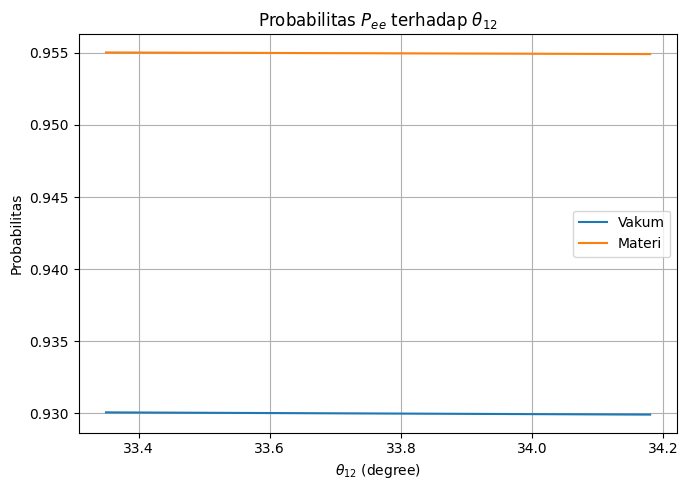

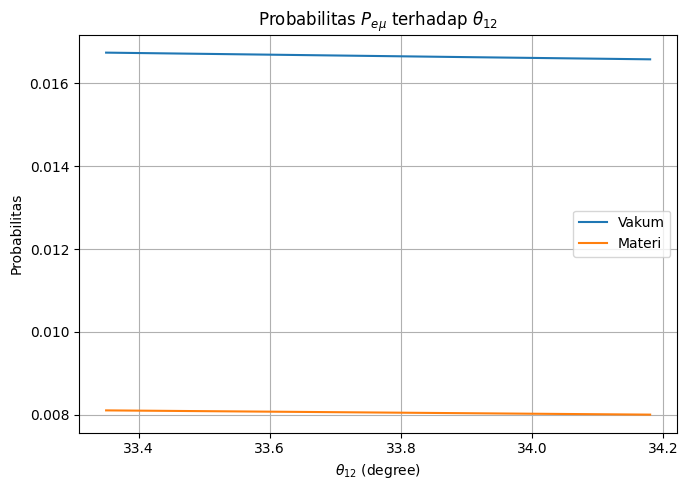

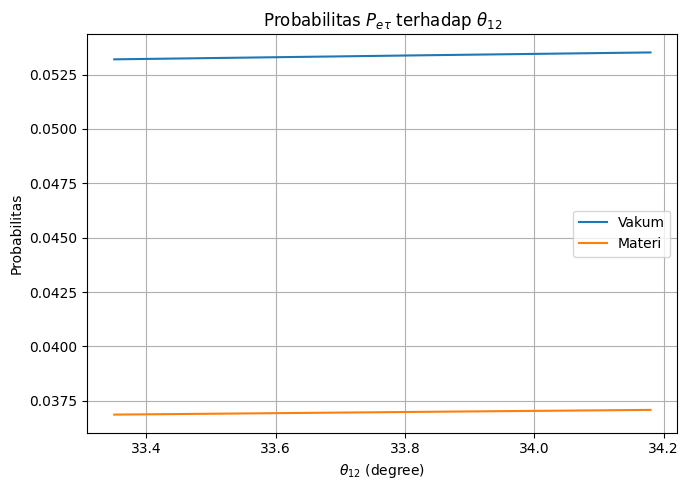

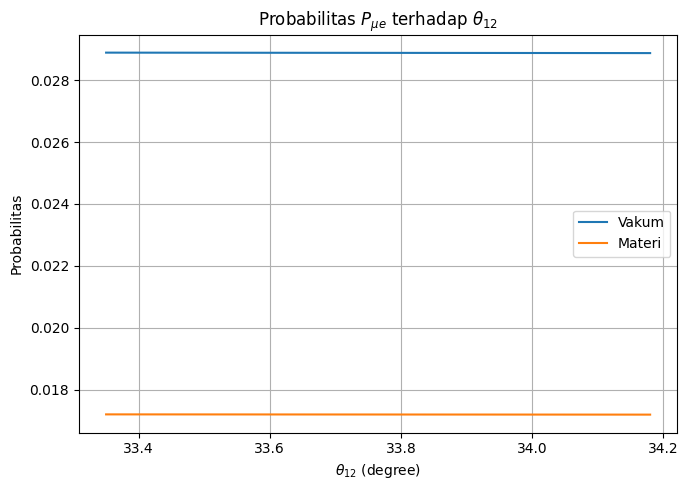

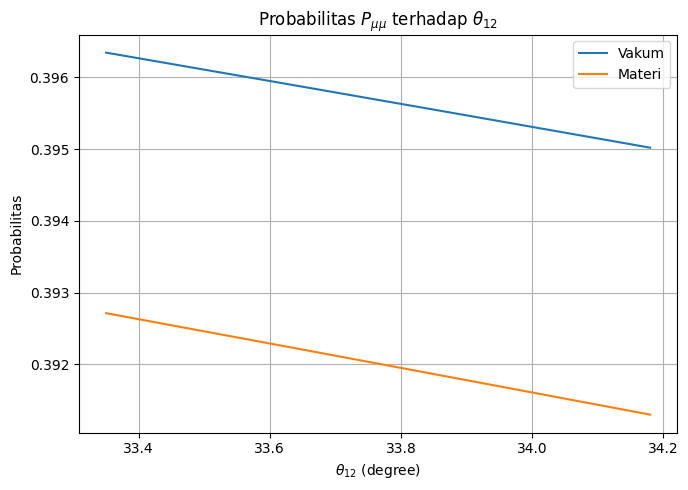

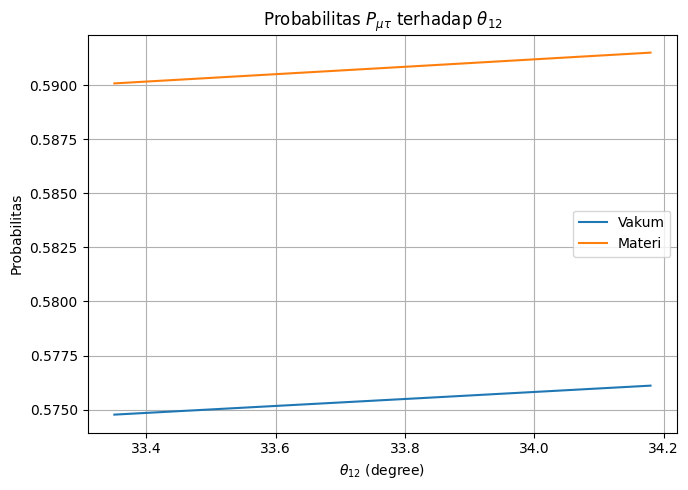

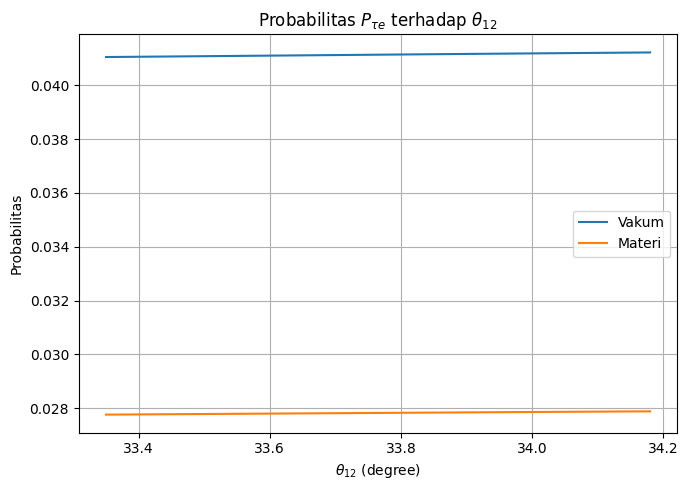

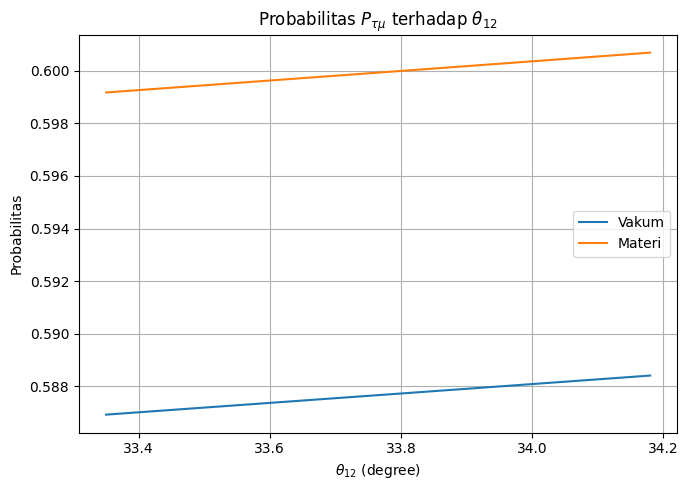

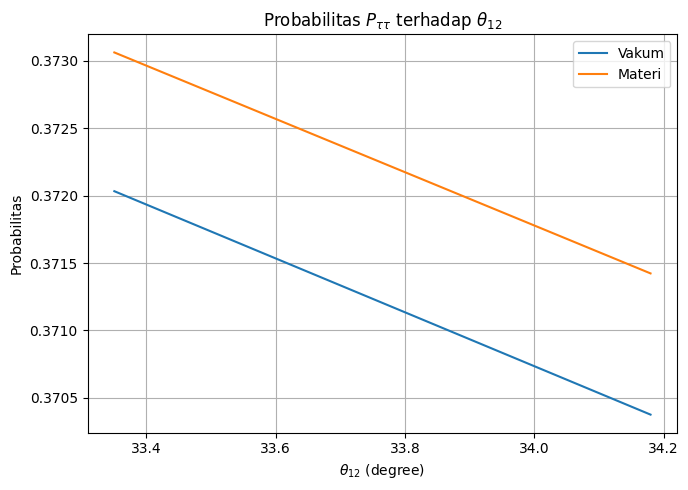

In [ ]:
plot_9_compare_vacuum_matter(
    df_vac=df_vac_theta12,
    df_mat=df_mat_theta12,
    x_column="theta12_deg",
    x_label=r"$\theta_{12}$ (degree)",
    parameter_label=r"$\theta_{12}$"
)

## variasi $\theta_{13}$

In [ ]:
df_vac_theta13 = vary_one_parameter_vacuum(
    parameter_name="theta13",
    parameter_values=theta13_samples
)

df_vac_theta13["theta13_deg"] = np.rad2deg(df_vac_theta13["theta13"])

display(df_vac_theta13.head())

,theta13,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau,theta13_deg
0,0.148528,0.930398,0.016520,0.053081,0.028687,0.395831,0.575482,0.040914,0.587649,0.371437,8.510003
1,0.148528,0.930398,0.016521,0.053081,0.028687,0.395831,0.575482,0.040915,0.587649,0.371437,8.510027
2,0.148528,0.930398,0.016521,0.053082,0.028688,0.395831,0.575482,0.040915,0.587649,0.371437,8.510044
3,0.148529,0.930397,0.016521,0.053082,0.028688,0.395831,0.575481,0.040915,0.587648,0.371437,8.510099
4,0.148530,0.930396,0.016521,0.053082,0.028688,0.395831,0.575481,0.040915,0.587648,0.371437,8.510152


In [ ]:
df_mat_theta13 = vary_one_parameter_matter(
    parameter_name="theta13",
    parameter_values=theta13_samples
)

df_mat_theta13["theta13_deg"] = np.rad2deg(df_mat_theta13["theta13"])

display(df_mat_theta13.head())

,theta13,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau,theta13_deg
0,0.148528,0.955215,0.007992,0.036792,0.017095,0.392178,0.590727,0.02769,0.599830,0.372481,8.510003
1,0.148528,0.955215,0.007992,0.036792,0.017095,0.392178,0.590727,0.02769,0.599829,0.372481,8.510027
2,0.148528,0.955215,0.007992,0.036792,0.017095,0.392178,0.590727,0.02769,0.599829,0.372481,8.510044
3,0.148529,0.955215,0.007993,0.036793,0.017095,0.392178,0.590727,0.02769,0.599829,0.372481,8.510099
4,0.148530,0.955214,0.007993,0.036793,0.017095,0.392178,0.590726,0.02769,0.599829,0.372481,8.510152


In [ ]:
df_vac_theta13, df_mat_theta13, df_sensitivitas_theta13 = (
    analyze_numerical_gradient(
        df_vac=df_vac_theta13,
        df_mat=df_mat_theta13,
        x_column="theta13_deg",
        parameter_label="theta13"
    )
)

display(df_sensitivitas_theta13)

,Probabilitas,Gradien rata-rata vakum,Gradien rata-rata materi,Maks |gradien| vakum,Maks |gradien| materi,Delta P vakum,Delta P materi
0,Pee,-0.013142,-0.007868,0.013288,0.007973,-0.002891,-0.001731
1,Peμ,0.005129,0.002684,0.005218,0.002746,0.001128,0.000590
2,Peτ,0.008013,0.005184,0.008071,0.005227,0.001763,0.001140
3,Pμe,0.006482,0.003755,0.006568,0.003817,0.001426,0.000826
4,Pμμ,0.000791,0.000411,0.000804,0.000428,0.000174,0.000091
5,Pμτ,-0.007273,-0.004167,0.007346,0.004213,-0.001600,-0.000917
6,Pτe,0.006660,0.004113,0.006721,0.004156,0.001465,0.000905
7,Pτμ,-0.005920,-0.003095,0.005996,0.003141,-0.001302,-0.000681
8,Pττ,-0.000740,-0.001018,0.000756,0.001020,-0.000163,-0.000224


In [ ]:
df_gradient_theta13 = analyze_simple_gradient(
    df_vac=df_vac_theta13,
    df_mat=df_mat_theta13,
    x_column="theta13_deg",
    parameter_label="theta13"
)

display(df_gradient_theta13)

,Probabilitas,Delta P Vakum,Gradien Vakum,Arah Vakum,Delta P Materi,Gradien Materi,Arah Materi
0,Pee,-0.002891,-0.013142,Turun,-0.001731,-0.007868,Turun
1,Peμ,0.001128,0.005129,Naik,0.000590,0.002683,Naik
2,Peτ,0.001763,0.008013,Naik,0.001140,0.005184,Naik
3,Pμe,0.001426,0.006481,Naik,0.000826,0.003755,Naik
4,Pμμ,0.000174,0.000791,Naik,0.000091,0.000411,Naik
5,Pμτ,-0.001600,-0.007273,Turun,-0.000917,-0.004167,Turun
6,Pτe,0.001465,0.006660,Naik,0.000905,0.004113,Naik
7,Pτμ,-0.001302,-0.005920,Turun,-0.000681,-0.003095,Turun
8,Pττ,-0.000163,-0.000741,Turun,-0.000224,-0.001018,Turun


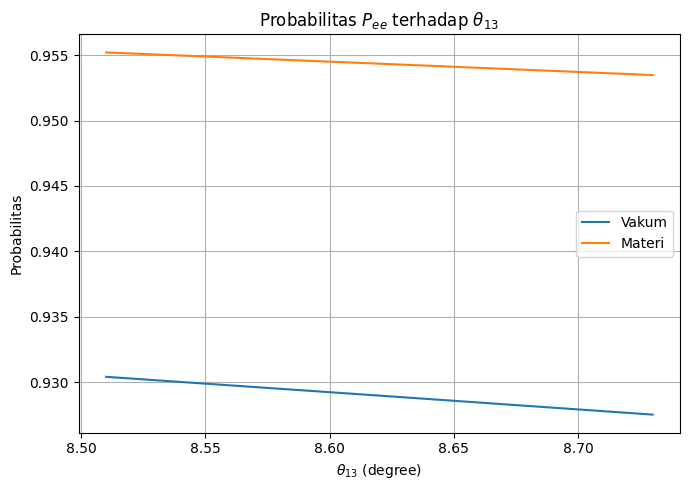

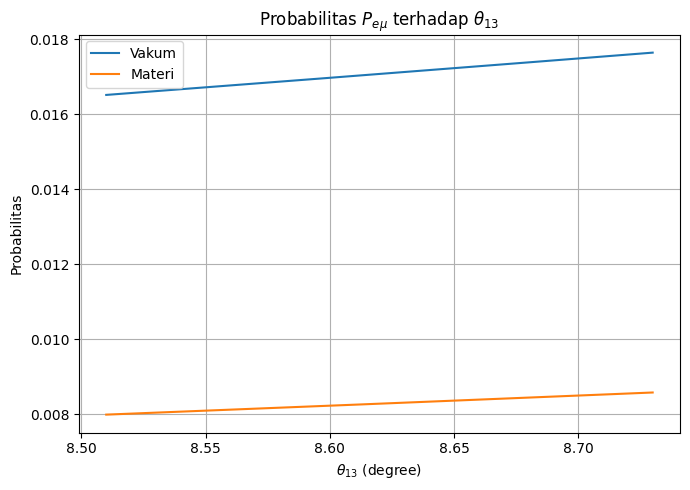

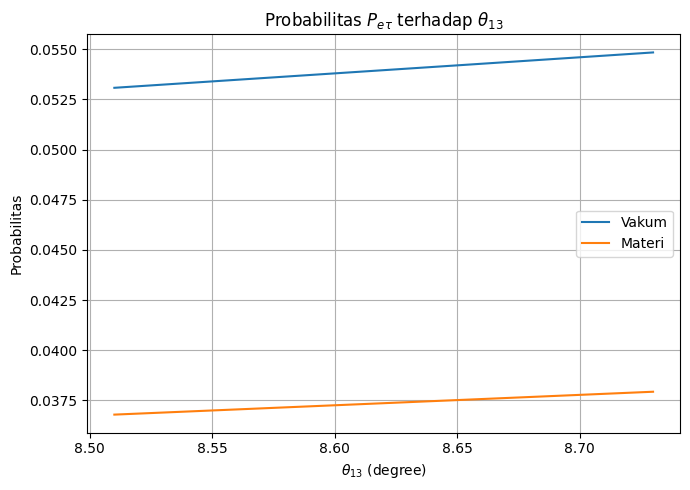

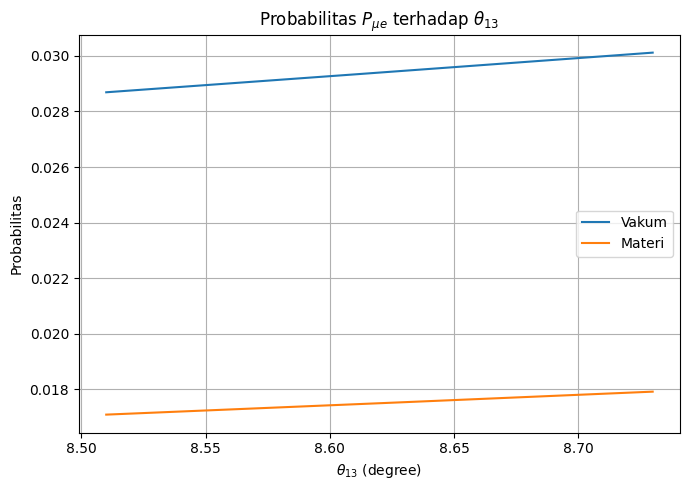

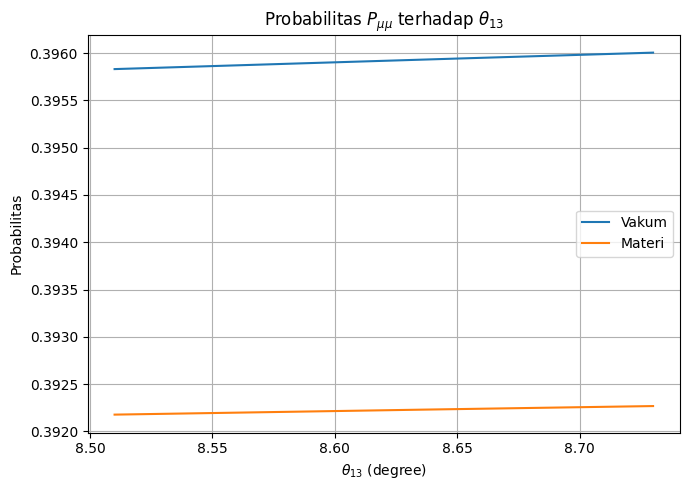

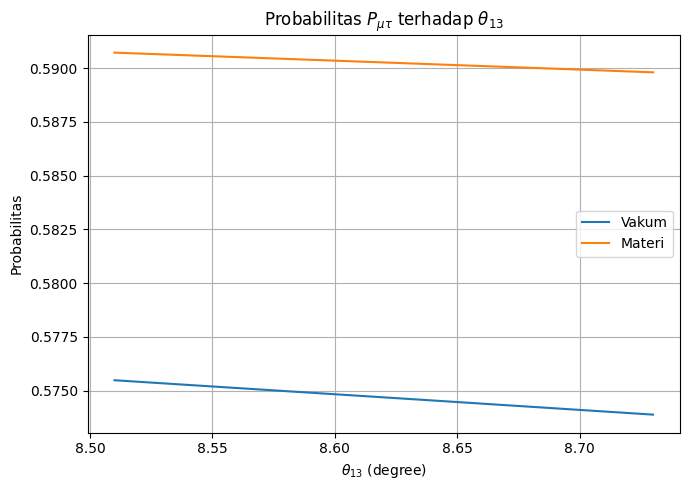

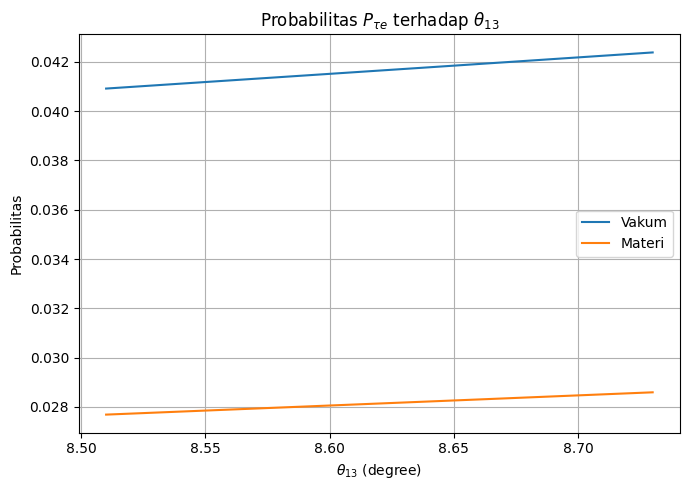

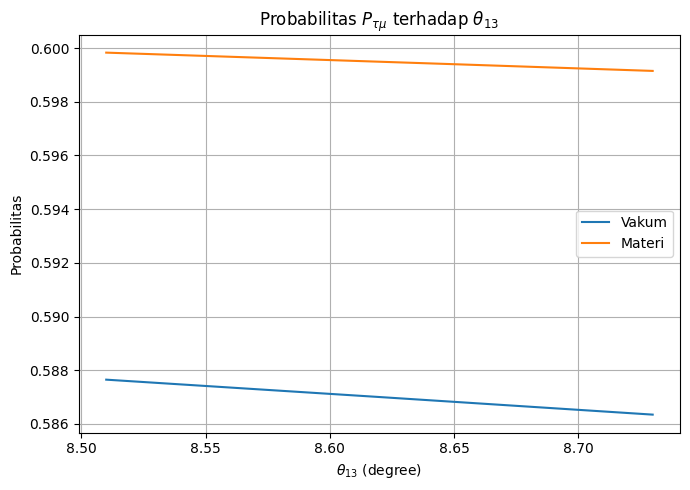

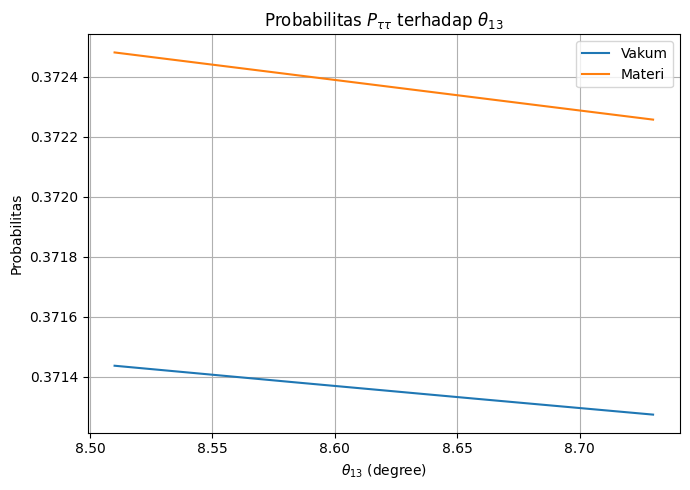

In [ ]:
plot_9_compare_vacuum_matter(
    df_vac=df_vac_theta13,
    df_mat=df_mat_theta13,
    x_column="theta13_deg",
    x_label=r"$\theta_{13}$ (degree)",
    parameter_label=r"$\theta_{13}$"
)

## variasi $\theta_{23}$

In [ ]:
df_vac_theta23 = vary_one_parameter_vacuum(
    parameter_name="theta23",
    parameter_values=theta23_samples
)

df_vac_theta23["theta23_deg"] = np.rad2deg(df_vac_theta23["theta23"])

display(df_vac_theta23.head(5000))

,theta23,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau,theta23_deg
0,0.741775,0.930008,0.011326,0.058666,0.023613,0.390354,0.586033,0.046379,0.598319,0.355302,42.500550
1,0.741778,0.930008,0.011326,0.058666,0.023613,0.390354,0.586033,0.046379,0.598320,0.355301,42.500730
2,0.741782,0.930008,0.011327,0.058665,0.023613,0.390353,0.586034,0.046379,0.598321,0.355301,42.500999
3,0.741794,0.930008,0.011327,0.058665,0.023614,0.390350,0.586036,0.046378,0.598323,0.355299,42.501672
4,0.741797,0.930008,0.011327,0.058665,0.023614,0.390349,0.586037,0.046378,0.598323,0.355299,42.501841
...,...,...,...,...,...,...,...,...,...,...,...
4995,0.772286,0.930008,0.012631,0.057361,0.024960,0.385774,0.589266,0.045032,0.601595,0.353373,44.248705
4996,0.772293,0.930008,0.012631,0.057361,0.024961,0.385773,0.589266,0.045031,0.601596,0.353373,44.249106
4997,0.772293,0.930008,0.012631,0.057361,0.024961,0.385773,0.589266,0.045031,0.601596,0.353373,44.249157
4998,0.772304,0.930008,0.012632,0.057360,0.024961,0.385772,0.589267,0.045031,0.601596,0.353373,44.249756


In [ ]:
df_mat_theta23 = vary_one_parameter_matter(
    parameter_name="theta23",
    parameter_values=theta23_samples
)

df_mat_theta23["theta23_deg"] = np.rad2deg(df_mat_theta23["theta23"])

display(df_mat_theta23.head())

,theta23,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau,theta23_deg
0,0.741775,0.954982,0.005527,0.039491,0.014721,0.381951,0.603328,0.030297,0.612522,0.357181,42.500550
1,0.741778,0.954982,0.005527,0.039491,0.014721,0.381951,0.603328,0.030297,0.612522,0.357181,42.500730
2,0.741782,0.954982,0.005527,0.039491,0.014721,0.381950,0.603329,0.030297,0.612523,0.357180,42.500999
3,0.741794,0.954982,0.005527,0.039491,0.014721,0.381948,0.603331,0.030297,0.612525,0.357178,42.501672
4,0.741797,0.954982,0.005527,0.039491,0.014721,0.381947,0.603332,0.030297,0.612526,0.357178,42.501841


In [ ]:
df_vac_theta23, df_mat_theta23, df_sensitivitas_theta23 = (
    analyze_numerical_gradient(
        df_vac=df_vac_theta23,
        df_mat=df_mat_theta23,
        x_column="theta23_deg",
        parameter_label="theta23"
    )
)

display(df_sensitivitas_theta23)

,Probabilitas,Gradien rata-rata vakum,Gradien rata-rata materi,Maks |gradien| vakum,Maks |gradien| materi,Delta P vakum,Delta P materi
0,Pee,5.387200e-12,4.256435e-12,1.117587e-08,7.450581e-09,-2.220446e-16,-4.440892e-16
1,Peμ,7.463227e-04,3.382389e-04,7.707007e-04,3.559751e-04,1.305753e-03,5.918123e-04
2,Peτ,-7.463227e-04,-3.382389e-04,7.707007e-04,3.559751e-04,-1.305753e-03,-5.918123e-04
3,Pμe,7.707624e-04,3.565266e-04,7.819727e-04,3.644096e-04,1.348439e-03,6.237529e-04
4,Pμμ,-2.623272e-03,-2.005329e-03,3.862017e-03,3.283377e-03,-4.582565e-03,-3.501324e-03
5,Pμτ,1.852509e-03,1.648802e-03,3.102876e-03,2.934907e-03,3.234126e-03,2.877571e-03
6,Pτe,-7.707624e-04,-3.565266e-04,7.819727e-04,3.644096e-04,-1.348439e-03,-6.237529e-04
7,Pτμ,1.876949e-03,1.667090e-03,3.140389e-03,2.962977e-03,3.276812e-03,2.909512e-03
8,Pττ,-1.106187e-03,-1.310563e-03,2.381248e-03,2.614508e-03,-1.928373e-03,-2.285759e-03


In [ ]:
df_gradient_theta23 = analyze_simple_gradient(
    df_vac=df_vac_theta23,
    df_mat=df_mat_theta23,
    x_column="theta23_deg",
    parameter_label="theta23"
)

display(df_gradient_theta23)

,Probabilitas,Delta P Vakum,Gradien Vakum,Arah Vakum,Delta P Materi,Gradien Materi,Arah Materi
0,Pee,-2.220446e-16,-1.269255e-16,Turun,-4.440892e-16,-2.538509e-16,Turun
1,Peμ,1.305753e-03,7.463965e-04,Naik,5.918123e-04,3.382926e-04,Naik
2,Peτ,-1.305753e-03,-7.463965e-04,Turun,-5.918123e-04,-3.382926e-04,Turun
3,Pμe,1.348439e-03,7.707965e-04,Naik,6.237529e-04,3.565505e-04,Naik
4,Pμμ,-4.582565e-03,-2.619492e-03,Turun,-3.501324e-03,-2.001432e-03,Turun
5,Pμτ,3.234126e-03,1.848696e-03,Naik,2.877571e-03,1.644881e-03,Naik
6,Pτe,-1.348439e-03,-7.707965e-04,Turun,-6.237529e-04,-3.565505e-04,Turun
7,Pτμ,3.276812e-03,1.873096e-03,Naik,2.909512e-03,1.663139e-03,Naik
8,Pττ,-1.928373e-03,-1.102299e-03,Turun,-2.285759e-03,-1.306589e-03,Turun


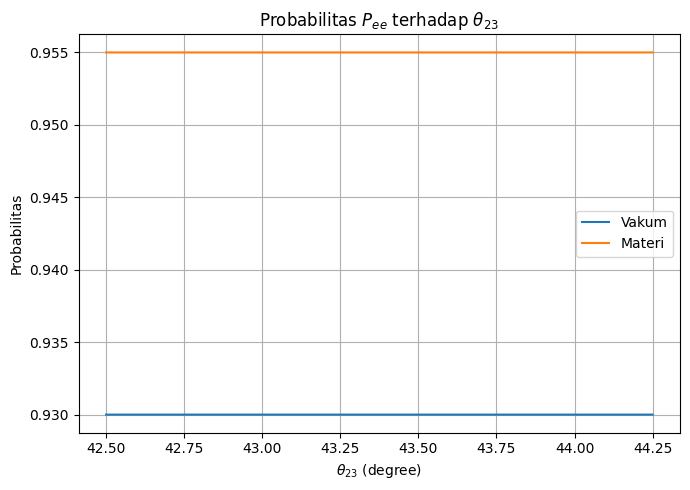

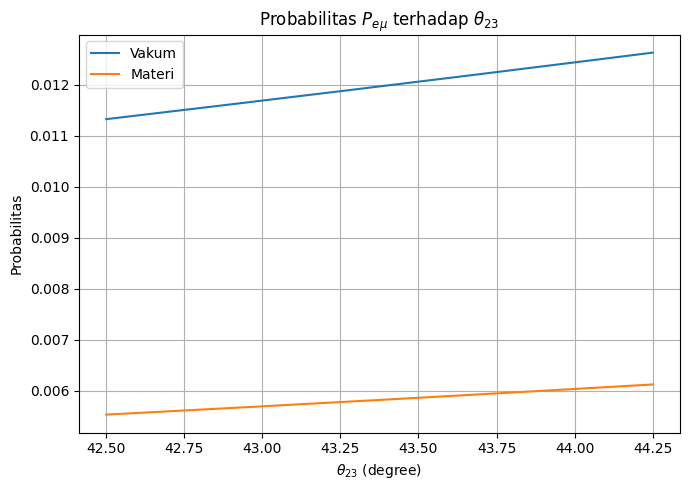

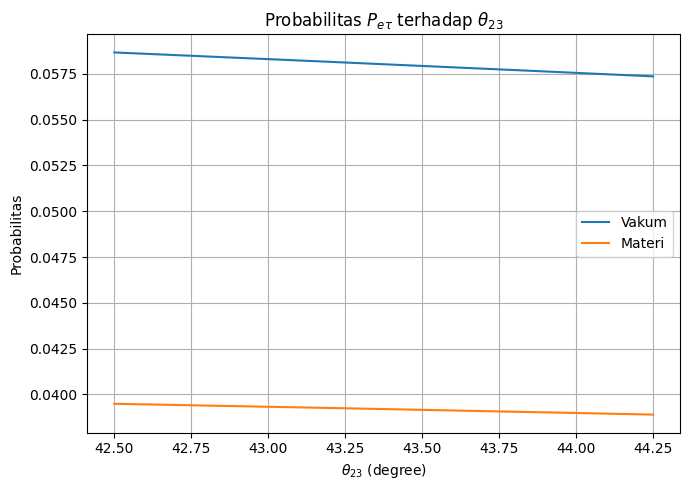

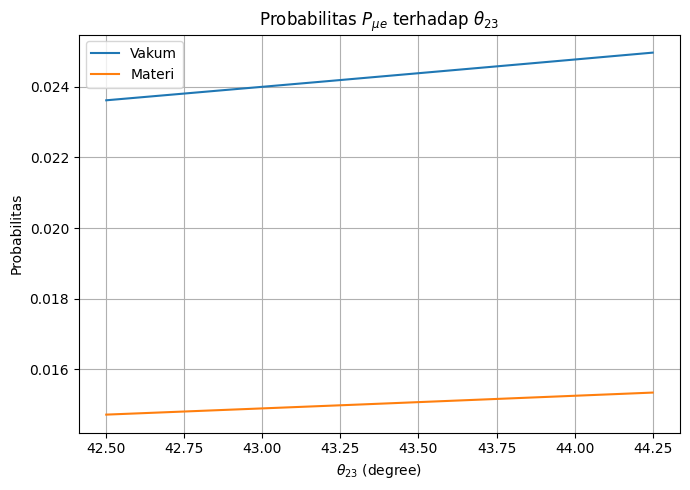

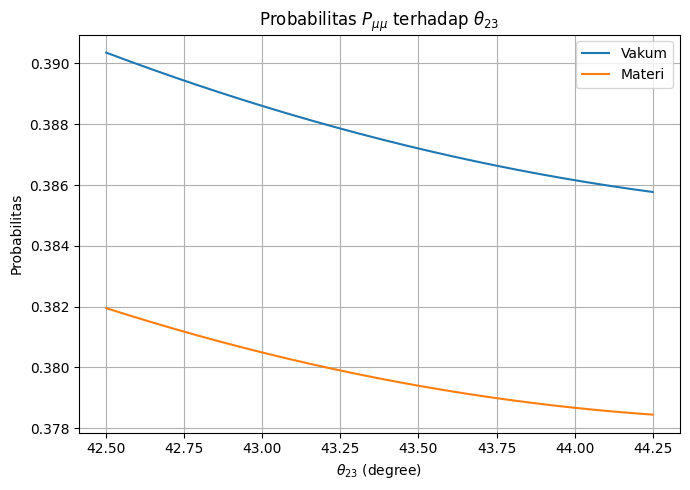

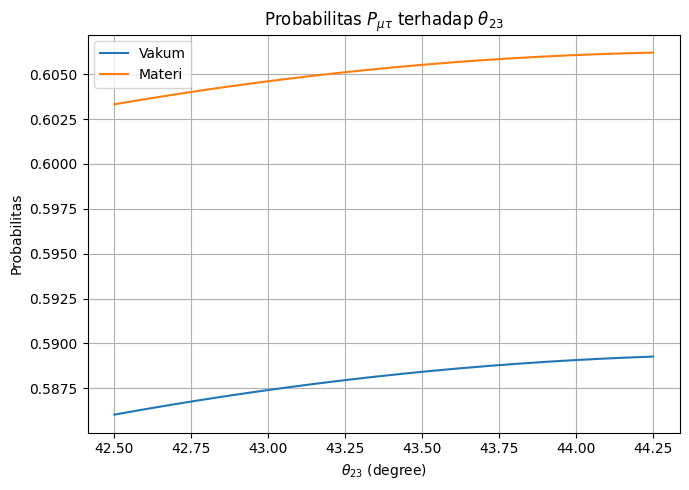

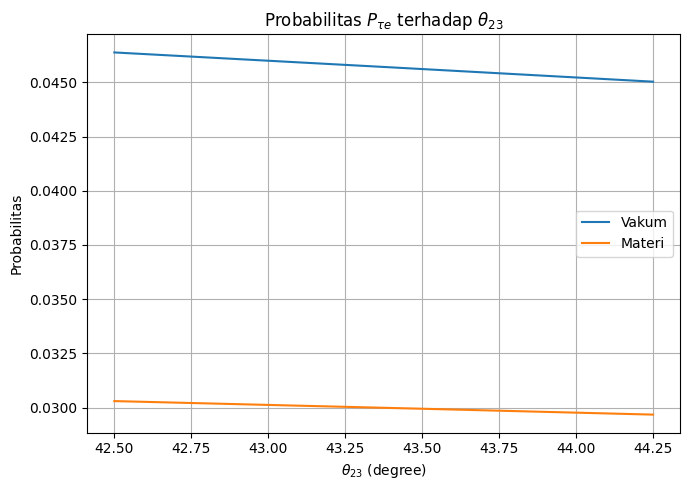

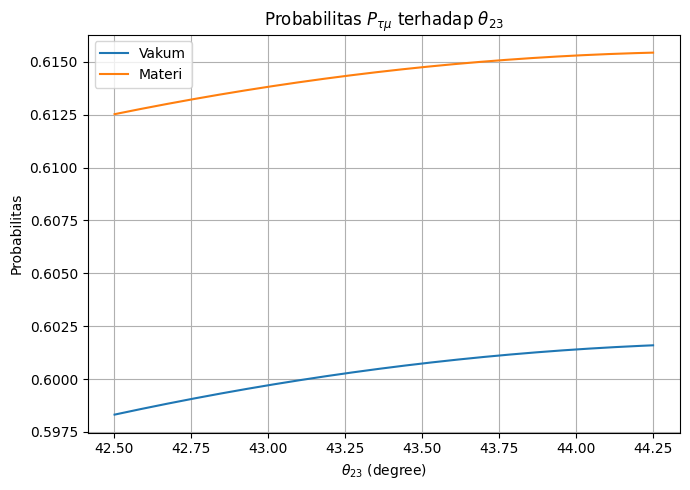

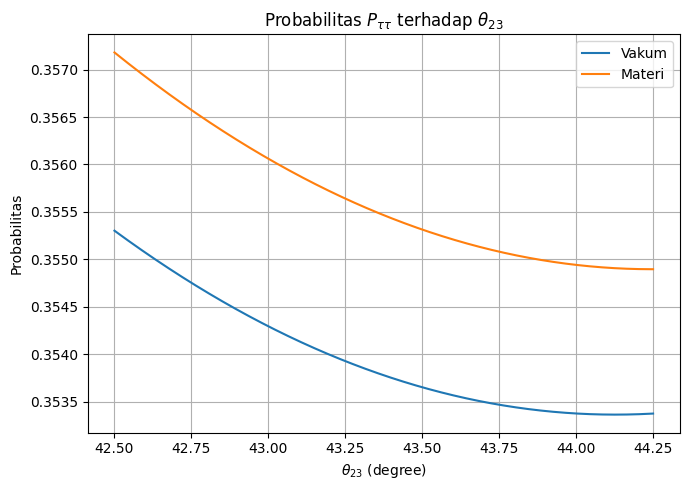

In [ ]:
plot_9_compare_vacuum_matter(
    df_vac=df_vac_theta23,
    df_mat=df_mat_theta23,
    x_column="theta23_deg",
    x_label=r"$\theta_{23}$ (degree)",
    parameter_label=r"$\theta_{23}$"
)

## variasi $\delta _{CP}$

In [ ]:
df_vac_delta_cp = vary_one_parameter_vacuum(
    parameter_name="delta_cp",
    parameter_values=delta_cp_samples
)

df_vac_delta_cp["delta_cp_deg"] = np.rad2deg(df_vac_delta_cp["delta_cp"])

display(df_vac_delta_cp.head())

,delta_cp,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau,delta_cp_deg
0,3.071800,0.930008,0.023565,0.046427,0.020653,0.396629,0.582717,0.049339,0.579806,0.370855,176.001193
1,3.071834,0.930008,0.023564,0.046428,0.020654,0.396629,0.582717,0.049338,0.579806,0.370855,176.003139
2,3.071897,0.930008,0.023563,0.046429,0.020655,0.396630,0.582715,0.049337,0.579808,0.370855,176.006745
3,3.072379,0.930008,0.023552,0.046440,0.020665,0.396630,0.582705,0.049328,0.579818,0.370855,176.034358
4,3.072481,0.930008,0.023550,0.046442,0.020667,0.396630,0.582703,0.049325,0.579820,0.370855,176.040200


In [ ]:
df_mat_delta_cp = vary_one_parameter_matter(
    parameter_name="delta_cp",
    parameter_values=delta_cp_samples
)

df_mat_delta_cp["delta_cp_deg"] = np.rad2deg(df_mat_delta_cp["delta_cp"])

display(df_mat_delta_cp.head())

,delta_cp,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau,delta_cp_deg
0,3.071800,0.954982,0.013237,0.031781,0.011058,0.392840,0.596102,0.033960,0.593924,0.372117,176.001193
1,3.071834,0.954982,0.013236,0.031782,0.011058,0.392840,0.596102,0.033959,0.593924,0.372117,176.003139
2,3.071897,0.954982,0.013235,0.031783,0.011059,0.392840,0.596101,0.033959,0.593925,0.372116,176.006745
3,3.072379,0.954982,0.013227,0.031791,0.011066,0.392840,0.596093,0.033951,0.593932,0.372116,176.034358
4,3.072481,0.954982,0.013226,0.031792,0.011068,0.392841,0.596091,0.033950,0.593934,0.372116,176.040200


In [ ]:
# Analisis gradien numerik delta CP
df_vac_delta_cp, df_mat_delta_cp, df_sensitivitas_delta_cp = (
    analyze_numerical_gradient(
        df_vac=df_vac_delta_cp,
        df_mat=df_mat_delta_cp,
        x_column="delta_cp_deg",
        parameter_label="delta CP"
    )
)

display(df_sensitivitas_delta_cp)

,Probabilitas,Gradien rata-rata vakum,Gradien rata-rata materi,Maks |gradien| vakum,Maks |gradien| materi,Delta P vakum,Delta P materi
0,Pee,-4.693574e-15,-3.264426e-14,5.820766e-11,5.820766e-11,2.220446e-16,0.000000
1,Peμ,-1.851035e-04,-1.399138e-04,3.831418e-04,2.864713e-04,-1.160537e-02,-0.008770
2,Peτ,1.851035e-04,1.399138e-04,3.831418e-04,2.864713e-04,1.160537e-02,0.008770
3,Pμe,4.308776e-04,3.210105e-04,4.607519e-04,3.428057e-04,2.670466e-02,0.019896
4,Pμμ,-1.418836e-04,-1.186004e-04,2.741899e-04,2.286472e-04,-8.717740e-03,-0.007287
5,Pμτ,-2.889940e-04,-2.024101e-04,3.666775e-04,2.766507e-04,-1.798692e-02,-0.012609
6,Pτe,-4.308776e-04,-3.210105e-04,4.607519e-04,3.428057e-04,-2.670466e-02,-0.019896
7,Pτμ,3.269870e-04,2.585142e-04,3.672349e-04,2.806771e-04,2.032311e-02,0.016058
8,Pττ,1.038905e-04,6.249626e-05,2.039759e-04,1.236854e-04,6.381549e-03,0.003838


In [ ]:
df_gradient_delta_cp = analyze_simple_gradient(
    df_vac=df_vac_delta_cp,
    df_mat=df_mat_delta_cp,
    x_column="delta_cp_deg",
    parameter_label="delta CP"
)

display(df_gradient_delta_cp)

,Probabilitas,Delta P Vakum,Gradien Vakum,Arah Vakum,Delta P Materi,Gradien Materi,Arah Materi
0,Pee,2.220446e-16,3.583014e-18,Naik,0.000000,0.000000,Tetap
1,Peμ,-1.160537e-02,-1.872696e-04,Turun,-0.008770,-0.000142,Turun
2,Peτ,1.160537e-02,1.872696e-04,Naik,0.008770,0.000142,Naik
3,Pμe,2.670466e-02,4.309187e-04,Naik,0.019896,0.000321,Naik
4,Pμμ,-8.717740e-03,-1.406735e-04,Turun,-0.007287,-0.000118,Turun
5,Pμτ,-1.798692e-02,-2.902452e-04,Turun,-0.012609,-0.000203,Turun
6,Pτe,-2.670466e-02,-4.309187e-04,Turun,-0.019896,-0.000321,Turun
7,Pτμ,2.032311e-02,3.279430e-04,Naik,0.016058,0.000259,Naik
8,Pττ,6.381549e-03,1.029756e-04,Naik,0.003838,0.000062,Naik


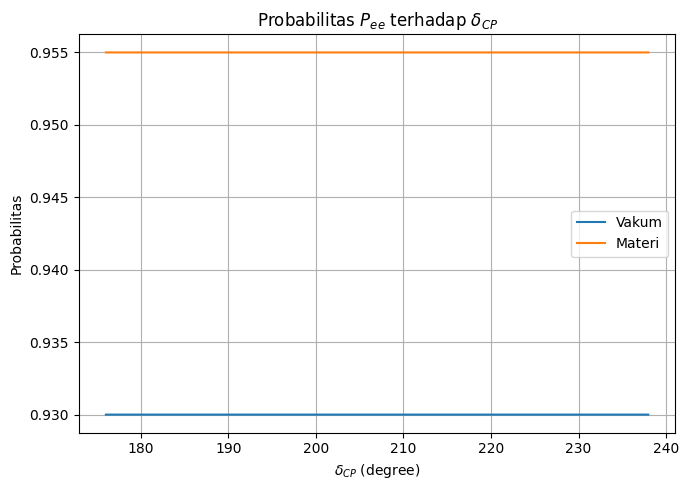

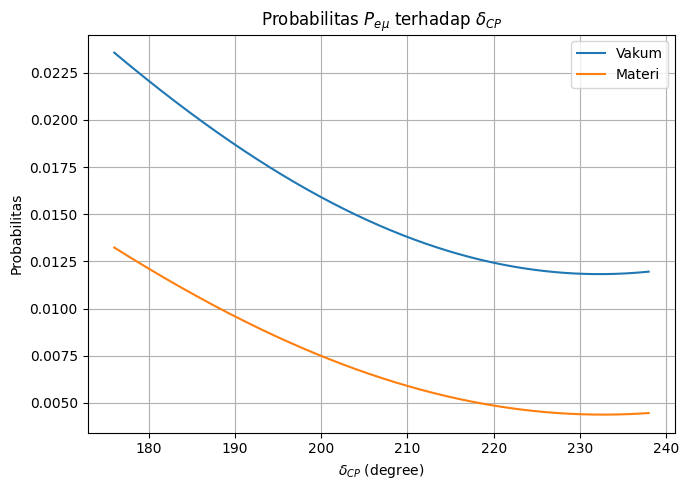

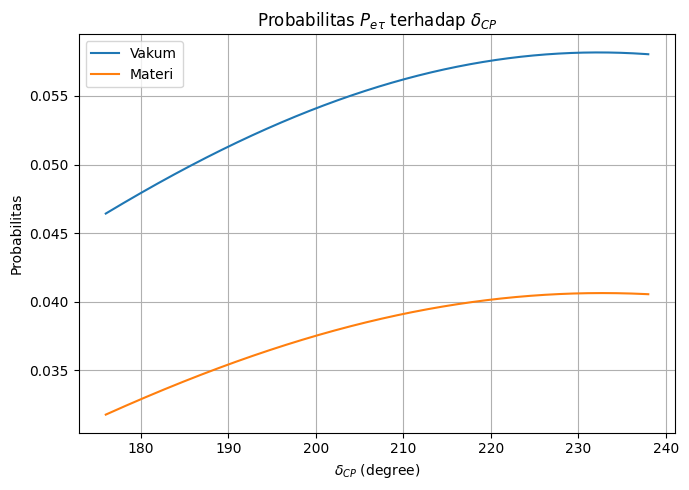

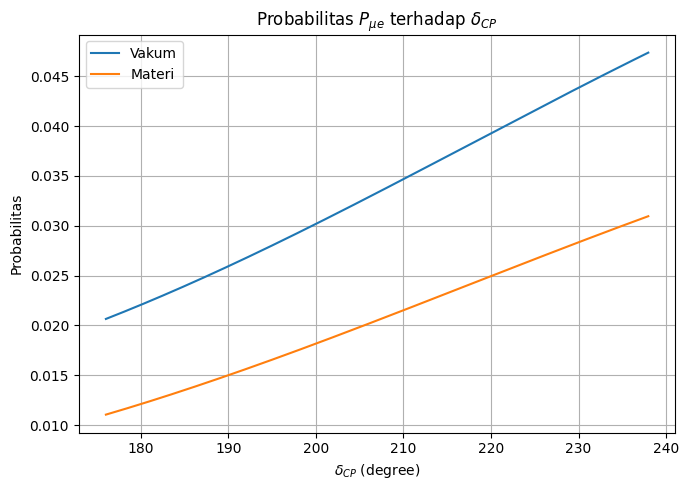

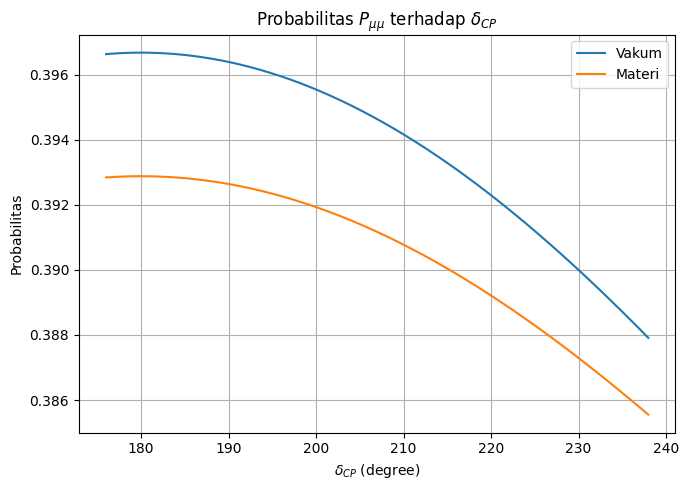

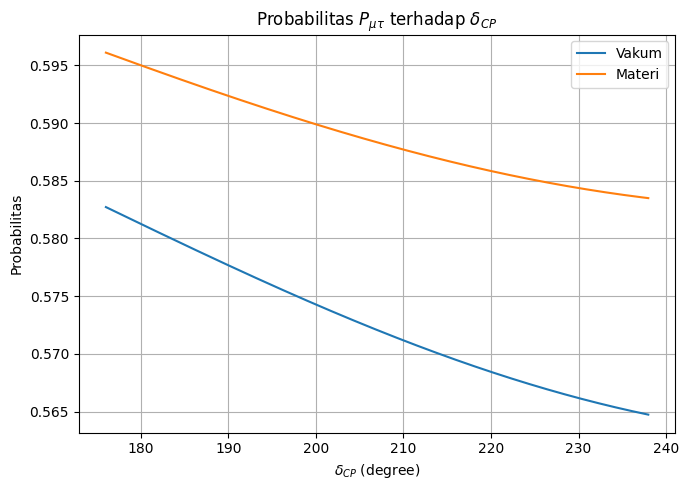

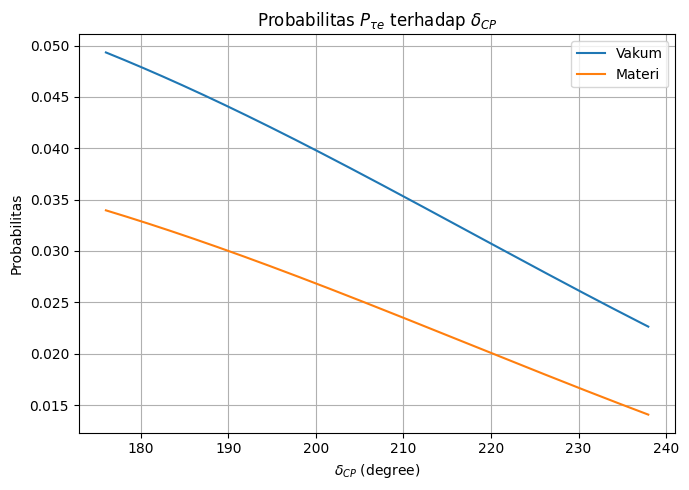

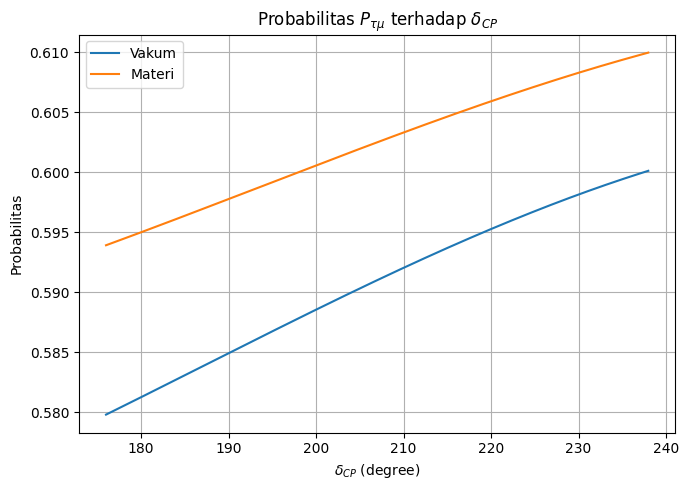

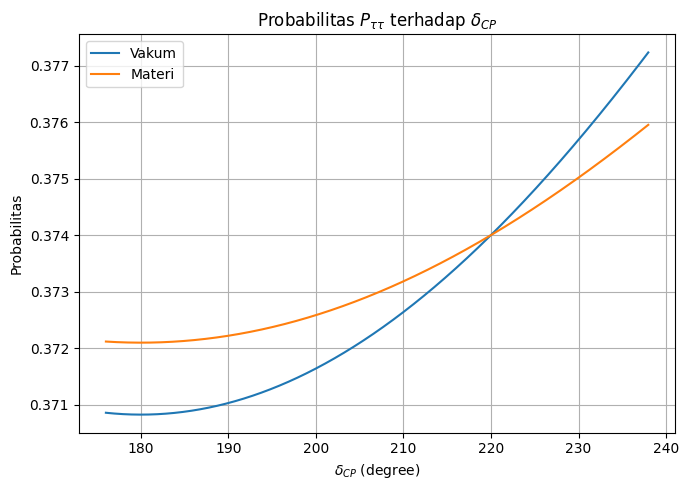

In [ ]:
plot_9_compare_vacuum_matter(
    df_vac=df_vac_delta_cp,
    df_mat=df_mat_delta_cp,
    x_column="delta_cp_deg",
    x_label=r"$\delta_{CP}$ (degree)",
    parameter_label=r"$\delta_{CP}$"
)

## variasi $\Delta m_{21}^2$

In [ ]:
df_vac_dm21 = vary_one_parameter_vacuum(
    parameter_name="dm21",
    parameter_values=dm21_samples
)

display(df_vac_dm21.head())

,dm21,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau
0,0.000074,0.929932,0.016622,0.053446,0.028869,0.396201,0.574930,0.041199,0.587177,0.371624
1,0.000074,0.929932,0.016622,0.053446,0.028869,0.396201,0.574930,0.041199,0.587177,0.371624
2,0.000074,0.929932,0.016622,0.053446,0.028869,0.396201,0.574930,0.041199,0.587177,0.371624
3,0.000074,0.929932,0.016622,0.053447,0.028869,0.396201,0.574929,0.041199,0.587177,0.371624
4,0.000074,0.929932,0.016622,0.053447,0.028869,0.396202,0.574929,0.041199,0.587177,0.371624


In [ ]:
df_mat_dm21 = vary_one_parameter_matter(
    parameter_name="dm21",
    parameter_values=dm21_samples
)

display(df_mat_dm21.head())

,dm21,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau
0,0.000074,0.95491,0.008042,0.037048,0.017205,0.392520,0.590275,0.027885,0.599438,0.372677
1,0.000074,0.95491,0.008042,0.037048,0.017205,0.392520,0.590275,0.027885,0.599438,0.372677
2,0.000074,0.95491,0.008041,0.037049,0.017205,0.392520,0.590275,0.027885,0.599438,0.372677
3,0.000074,0.95491,0.008041,0.037049,0.017205,0.392521,0.590274,0.027885,0.599438,0.372677
4,0.000074,0.95491,0.008041,0.037049,0.017205,0.392521,0.590274,0.027885,0.599438,0.372677


In [ ]:
# Analisis gradien numerik Delta m21^2
df_vac_dm21, df_mat_dm21, df_sensitivitas_dm21 = (
    analyze_numerical_gradient(
        df_vac=df_vac_dm21,
        df_mat=df_mat_dm21,
        x_column="dm21",
        parameter_label="Delta m21 kuadrat"
    )
)

display(df_sensitivitas_dm21)

,Probabilitas,Gradien rata-rata vakum,Gradien rata-rata materi,Maks |gradien| vakum,Maks |gradien| materi,Delta P vakum,Delta P materi
0,Pee,-286.440485,-271.288310,290.566028,275.419881,-0.000556,-0.000526
1,Peμ,-183.008829,-108.009255,184.643886,109.810756,-0.000355,-0.000209
2,Peτ,469.449312,379.297565,471.939490,381.627145,0.000911,0.000736
3,Pμe,-36.449060,-1.497082,37.582738,2.840156,-0.000071,-0.000003
4,Pμμ,1279.862365,1217.401714,1280.059825,1217.617557,0.002482,0.002361
5,Pμτ,-1243.413304,-1215.904633,1244.744044,1217.023186,-0.002412,-0.002358
6,Pτe,322.889543,272.785392,325.881809,275.573959,0.000626,0.000529
7,Pτμ,-1096.853535,-1109.392462,1098.686349,1110.969996,-0.002127,-0.002152
8,Pττ,773.963991,836.607069,775.118839,837.812882,0.001501,0.001623


In [ ]:
df_gradient_dm21 = analyze_simple_gradient(
    df_vac=df_vac_dm21,
    df_mat=df_mat_dm21,
    x_column="dm21",
    parameter_label="Delta m21 kuadrat"
)

display(df_gradient_dm21)

,Probabilitas,Delta P Vakum,Gradien Vakum,Arah Vakum,Delta P Materi,Gradien Materi,Arah Materi
0,Pee,-0.000556,-286.439355,Turun,-0.000526,-271.287178,Turun
1,Peμ,-0.000355,-183.009279,Turun,-0.000209,-108.009751,Turun
2,Peτ,0.000911,469.448634,Naik,0.000736,379.296930,Naik
3,Pμe,-0.000071,-36.449371,Turun,-0.000003,-1.497451,Turun
4,Pμμ,0.002482,1279.862323,Naik,0.002361,1217.401790,Naik
5,Pμτ,-0.002412,-1243.412952,Turun,-0.002358,-1215.904339,Turun
6,Pτe,0.000626,322.888726,Naik,0.000529,272.784630,Naik
7,Pτμ,-0.002127,-1096.853044,Turun,-0.002152,-1109.392039,Turun
8,Pττ,0.001501,773.964318,Naik,0.001623,836.607409,Naik


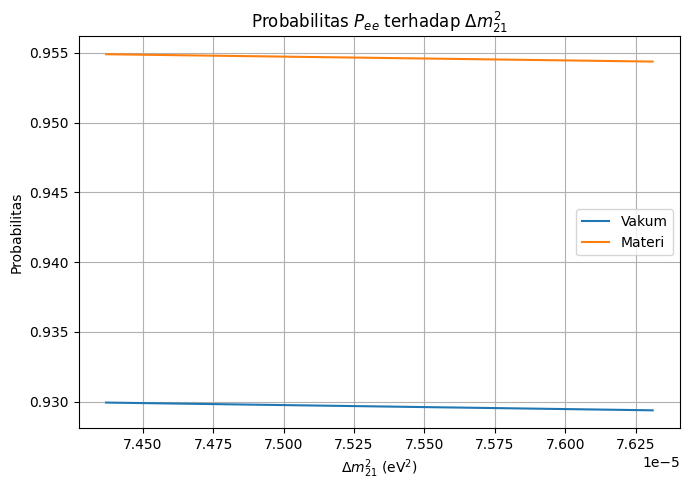

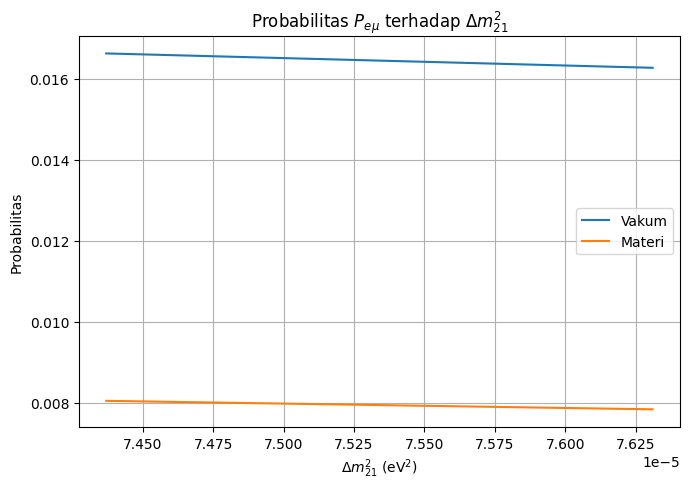

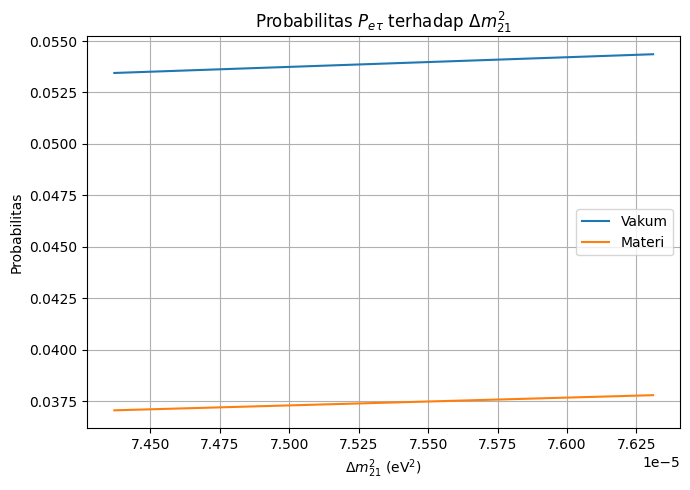

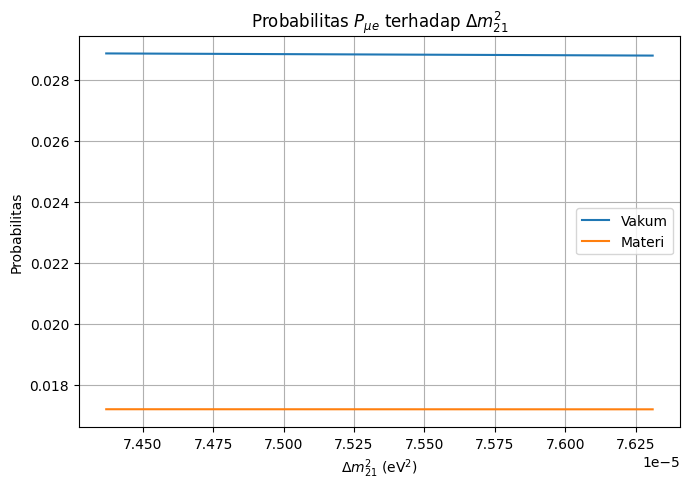

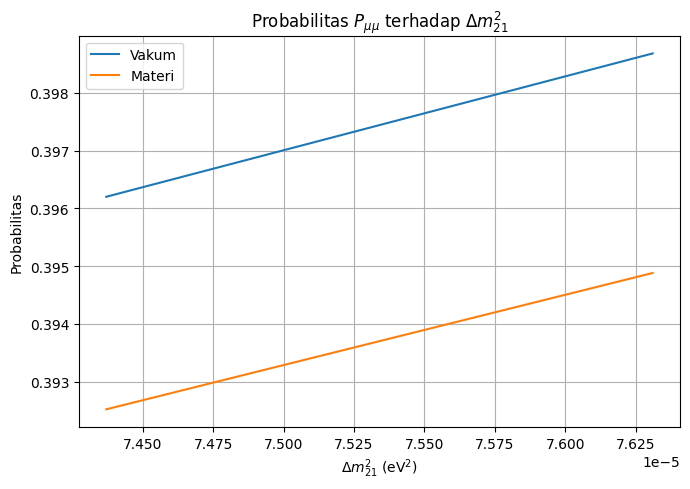

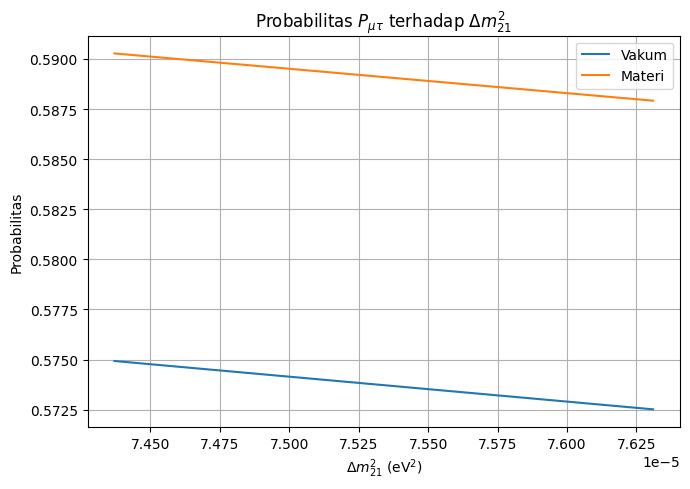

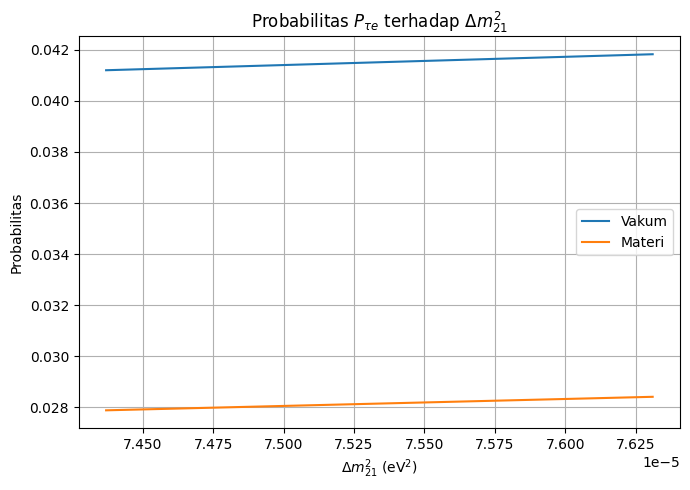

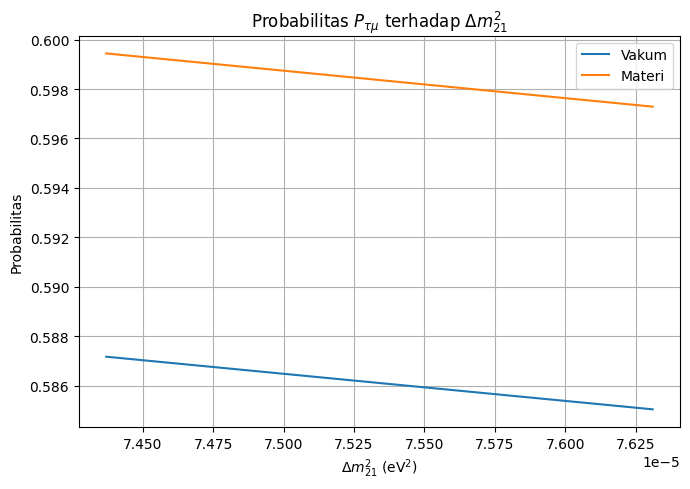

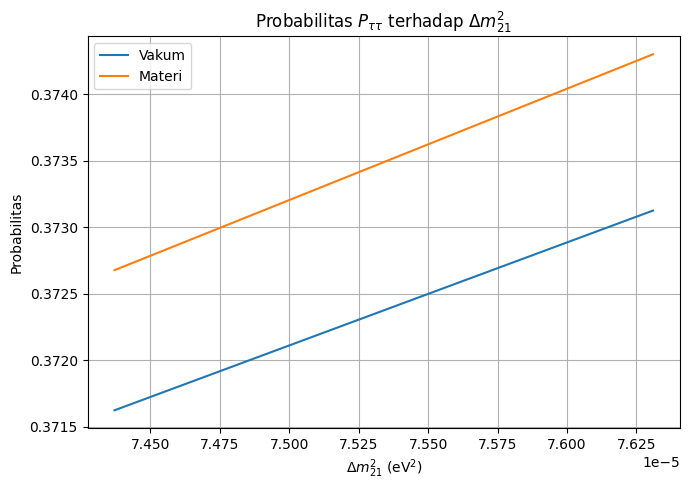

In [ ]:
plot_9_compare_vacuum_matter(
    df_vac=df_vac_dm21,
    df_mat=df_mat_dm21,
    x_column="dm21",
    x_label=r"$\Delta m_{21}^{2}$ (eV$^2$)",
    parameter_label=r"$\Delta m_{21}^{2}$"
)

## variasi $\Delta m_{31}^2$

In [ ]:
df_vac_dm31 = vary_one_parameter_vacuum(
    parameter_name="dm31",
    parameter_values=dm31_samples
)

display(df_vac_dm31.head())

,dm31,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau
0,0.002491,0.933095,0.014944,0.051961,0.026462,0.432397,0.541141,0.040443,0.552658,0.406898
1,0.002491,0.933094,0.014945,0.051961,0.026463,0.432391,0.541146,0.040443,0.552664,0.406893
2,0.002491,0.933094,0.014945,0.051961,0.026463,0.432391,0.541146,0.040443,0.552664,0.406893
3,0.002491,0.933093,0.014945,0.051961,0.026463,0.432381,0.541155,0.040443,0.552674,0.406883
4,0.002491,0.933093,0.014946,0.051962,0.026464,0.432372,0.541164,0.040444,0.552683,0.406874


In [ ]:
df_mat_dm31 = vary_one_parameter_matter(
    parameter_name="dm31",
    parameter_values=dm31_samples
)

display(df_mat_dm31.head())

,dm31,P_e_e,P_e_mu,P_e_tau,P_mu_e,P_mu_mu,P_mu_tau,P_tau_e,P_tau_mu,P_tau_tau
0,0.002491,0.958515,0.006525,0.034961,0.014901,0.428123,0.556976,0.026585,0.565352,0.408064
1,0.002491,0.958514,0.006525,0.034961,0.014901,0.428118,0.556981,0.026585,0.565357,0.408058
2,0.002491,0.958514,0.006525,0.034961,0.014901,0.428117,0.556981,0.026585,0.565357,0.408058
3,0.002491,0.958513,0.006525,0.034961,0.014902,0.428108,0.556990,0.026585,0.565367,0.408048
4,0.002491,0.958512,0.006526,0.034962,0.014902,0.428098,0.556999,0.026585,0.565376,0.408039


In [ ]:
# Analisis gradien numerik Delta m31^2
df_vac_dm31, df_mat_dm31, df_sensitivitas_dm31 = (
    analyze_numerical_gradient(
        df_vac=df_vac_dm31,
        df_mat=df_mat_dm31,
        x_column="dm31",
        parameter_label="Delta m31 kuadrat"
    )
)

display(df_sensitivitas_dm31)

,Probabilitas,Gradien rata-rata vakum,Gradien rata-rata materi,Maks |gradien| vakum,Maks |gradien| materi,Delta P vakum,Delta P materi
0,Pee,-132.767770,-155.247310,135.809470,158.675997,-0.005444,-0.006363
1,Peμ,75.897541,69.820083,77.517212,75.414195,0.003111,0.002860
2,Peτ,56.870229,85.427227,61.796355,87.369904,0.002333,0.003503
3,Pμe,105.608066,102.833495,106.574348,108.447384,0.004329,0.004213
4,Pμμ,-1578.295368,-1552.204386,1599.545272,1572.539361,-0.064713,-0.063643
5,Pμτ,1472.687302,1449.370891,1495.247279,1475.755046,0.060384,0.059430
6,Pτe,27.159704,52.413815,31.511478,54.478685,0.001115,0.002150
7,Pτμ,1502.397827,1482.384303,1525.532157,1508.646264,0.061602,0.060783
8,Pττ,-1529.557532,-1534.798118,1557.043635,1563.124949,-0.062717,-0.062933


In [ ]:
df_gradient_dm31 = analyze_simple_gradient(
    df_vac=df_vac_dm31,
    df_mat=df_mat_dm31,
    x_column="dm31",
    parameter_label="Delta m31 kuadrat"
)

display(df_gradient_dm31)

,Probabilitas,Delta P Vakum,Gradien Vakum,Arah Vakum,Delta P Materi,Gradien Materi,Arah Materi
0,Pee,-0.005444,-132.797530,Turun,-0.006363,-155.211178,Turun
1,Peμ,0.003111,75.880456,Naik,0.002860,69.764934,Naik
2,Peτ,0.002333,56.917074,Naik,0.003503,85.446244,Naik
3,Pμe,0.004329,105.596640,Naik,0.004213,102.777480,Naik
4,Pμμ,-0.064713,-1578.508848,Turun,-0.063643,-1552.409056,Turun
5,Pμτ,0.060384,1472.912208,Naik,0.059430,1449.631576,Naik
6,Pτe,0.001115,27.200890,Naik,0.002150,52.433698,Naik
7,Pτμ,0.061602,1502.628392,Naik,0.060783,1482.644122,Naik
8,Pττ,-0.062717,-1529.829283,Turun,-0.062933,-1535.077820,Turun


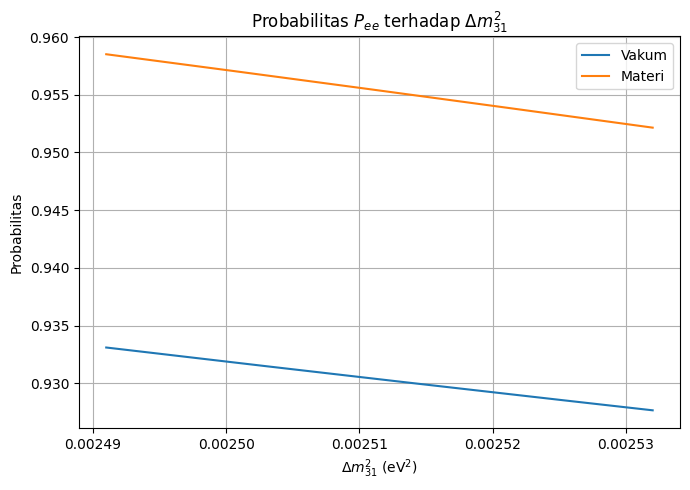

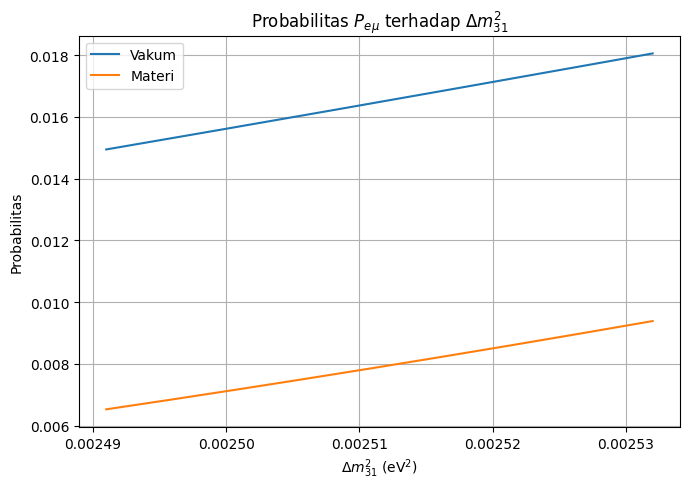

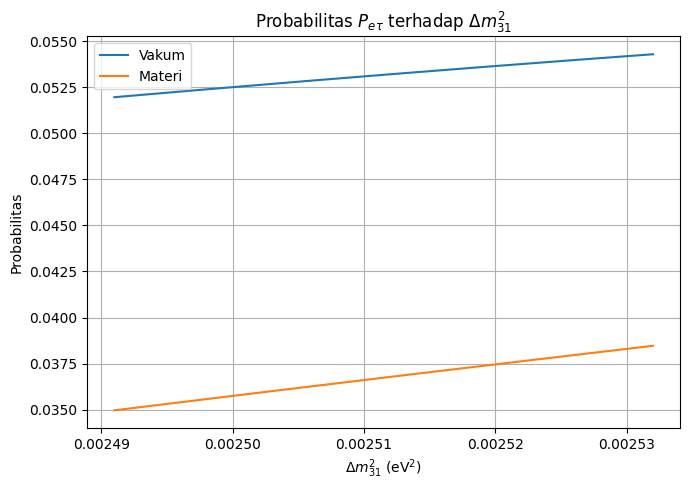

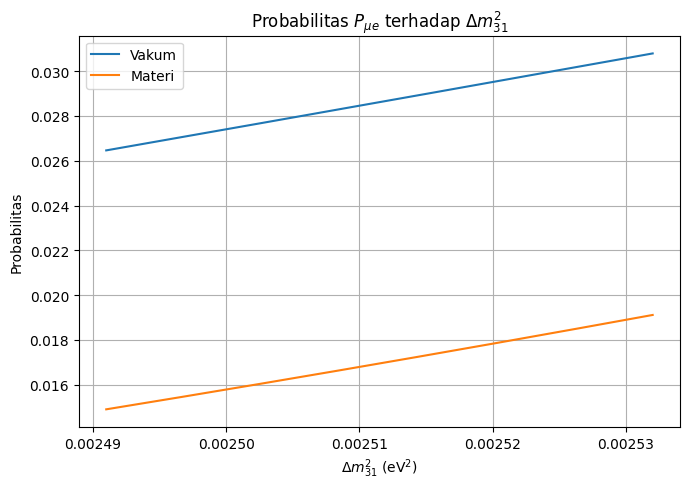

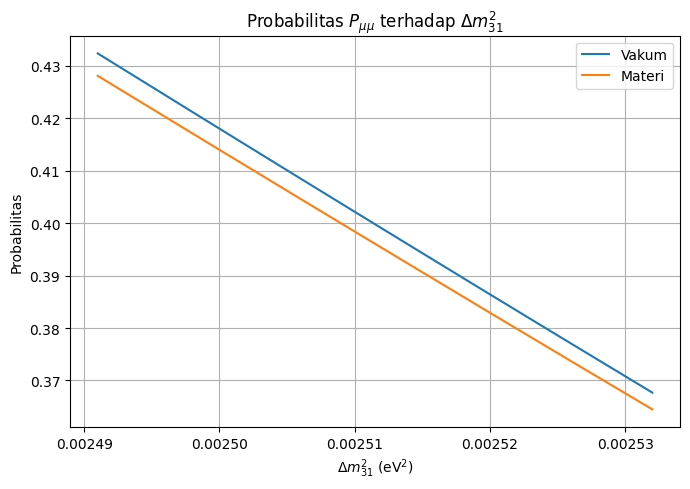

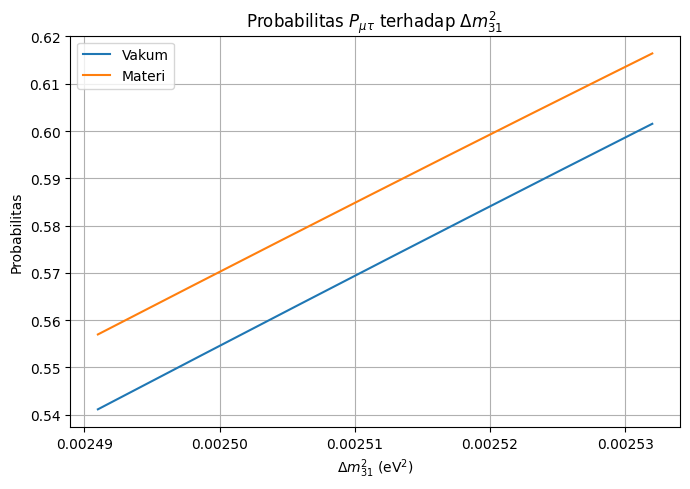

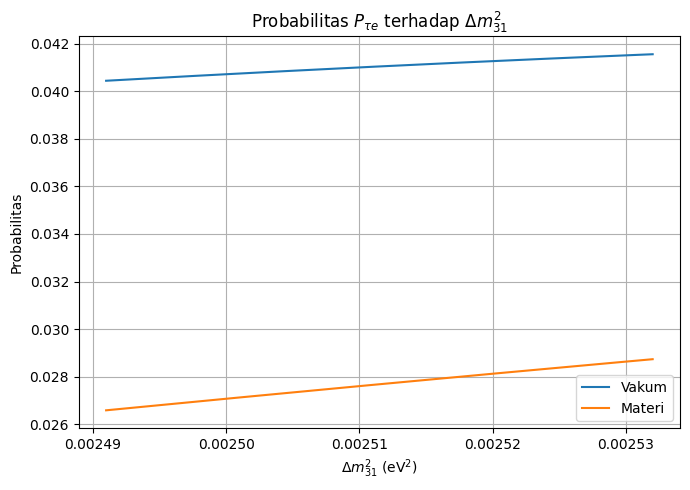

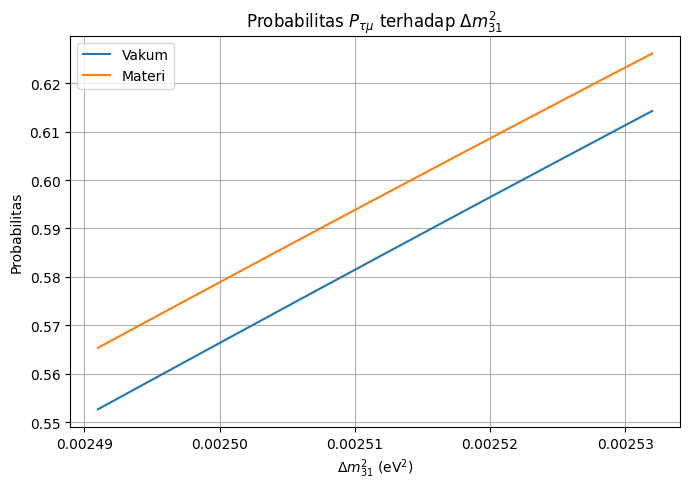

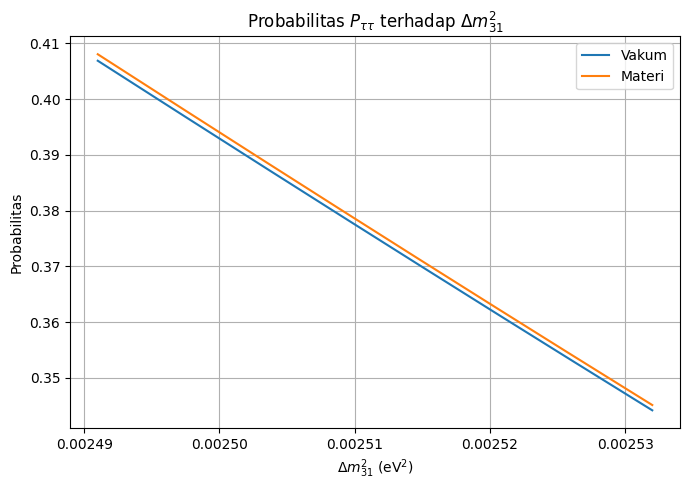

In [ ]:
plot_9_compare_vacuum_matter(
    df_vac=df_vac_dm31,
    df_mat=df_mat_dm31,
    x_column="dm31",
    x_label=r"$\Delta m_{31}^{2}$ (eV$^2$)",
    parameter_label=r"$\Delta m_{31}^{2}$"
)